# Loading of all required Data

In [1]:
import json

with open("codelist_raw.json", "r", encoding="utf-8") as f:
    raw = json.load(f)["content"]

print(raw[:2000])   # eyeball the actual layout — tables often come out
                     # with codes and labels on awkward, inconsistent lines

List of codes used in ASI schedule
I. Scheme Code (Block A Item 3):
Census – 1, Sample – 2
II. Sector Code (Block A Item 9):
Rural –1, Urban –2
III. Status of Unit (Code) (Block A Item 12)
Open . ....... ................................ ...................................................................................... .1
Existing with fixed assets and maintaining staff but not having production ........................... 2
Existing with fixed assets but not maintaining staff and not having production. .................... 3
Deleted (including cases of status code 3 for 3 years or more or non-existence or de-registration or
out of coverage or any other suitable reason for which deletion from frame is proposed by
NSO(FOD) .. ……………………………………………………………………………….. 4
Existing but non-response due to closure and owner / occupier is not traceable .................... 5
Non-response due to production not yet started or accounting year not closed during the year.… 7
Non-response due to other re

In [2]:
import json

for fname in ["CONCEPTS_AND_DEFINITIONS_raw.json"]:
    with open(fname, "r", encoding="utf-8") as f:
        raw = json.load(f)["content"]
    print(f"\n===== {fname} =====")
    print(raw[:1500])


===== CONCEPTS_AND_DEFINITIONS_raw.json =====
CONCEPTS AND DEFINITIONS
Important concepts and definitions used in ASI are explained below.
1. A number of accounting, economic and other terms related to the factories are used in conduct
of Annual Survey of Industries. For proper assessment and interpretation of ASI data, those are
given below.
2. Accounting Year: For the purpose of ASI, the accounting year is the period on which the
factory closes its books of account. With the enactment of Income Tax Act, by and large, the
accounting year of all factories is from April to March.
3. Reference Period: It corresponds to the financial year. For example, for ASI 2023-2024 the
reference period is the financial year commencing from 1st April 2023 and ending on 31st March
2024 or the accounting year of the factory ending on any date between 01.04.2023 to 31.03.2024.
4. Survey Period: Survey period is a period during which work of any Annual Survey of
Industries is undertaken. The survey perio

In [3]:
import json

for fname in ["Data_Structure_ASI_2023_24_raw.json"]:
    with open(fname, "r", encoding="utf-8") as f:
        raw = json.load(f)["content"]
    print(f"\n===== {fname} =====")
    print(raw[:1500])


===== Data_Structure_ASI_2023_24_raw.json =====
Data Structure of ASI 2023-2024
BLOCK-A (IDENTIFICATION BLOCK FOR OFFICIAL USE)
Srl.No. Field Name Sch. Ref. Description Type Width
1 YR - '24' for ASI 2023-2024 Character 2
2 BLK - Block code, Always 'A' Character 2
3 A1 Item 1 DSL Character 6
4 A2 Item 2 PSL No. Character 5
5 A3 Item 3 Scheme code (Census-1, Sample-2) Numeric 1
6 A4 Item4 Ind. Code as per Frame (4-digit Class of NIC-2008) Character 4
7 A5 Item 5 Ind Code as per Return (5-digit Sub-class of NIC-2008) Character 5
8 A7 Item 7 State Code Character 2
9 A8 Item 8 District code Character 2
10 A9 Item 9 Sector (Rural -1, Urban -2) Numeric 1
11 A10 Item 10 RO/SRO code Character 4
12 A11 Item 11 No. of units Numeric 3
13 A12 Item 12 Status of Unit Numeric 2
14 BONUS E Blk item 10 Bonus (in Rs.) Numeric 14
15 PF E Blk item 11 Contribution to provident & other funds (in Rs.) Numeric 14
16 WELFARE E Blk item 12 Workmen & staff welfare expenses (in Rs.) Numeric 14
17 MWDAYS E Blk it

In [4]:
import json

for fname in ["NIC_2008_raw.json"]:
    with open(fname, "r", encoding="utf-8") as f:
        raw = json.load(f)["content"]
    print(f"\n===== {fname} =====")
    print(raw[:1500])


===== NIC_2008_raw.json =====

National
Industrial
Classification
[All Economic Activities)
2008
Central Statistical Organisation
Ministry of Statistics and
Programme Implementation
Government of India
New Delhi
India

Preface
The Central Statistical Organisation of the Ministry of Statistics and Programme Implementation
being nodal statistical authority is vested with the responsibility of setting up standards for collection,
compilation and dissemination of statistical data. The official statistical data are required to be collected
and presented according to classification designed to facilitate their use for national economic policy
and for international comparison. Comparability of statistics available from various sources, on
different aspects of the economy, and usability of such data for economic analysis are prerequisite for
standardization of a system of classification.
2. The Central Statistical Organisation (CSO), which is responsible for coordination of statistical
activi

In [5]:
import pandas as pd

# colspecs = list of (start, end) character positions, 0-indexed, end-exclusive
# col_names = matching field names
# BOTH must come from Data_Structure_ASI_2023_24_raw.json — placeholders below

colspecs = [
    (0, 3),
    (3, 9),
    # ... fill in from your actual schema
]
col_names = [
    "block_code",
    "unit_id",
    # ... fill in from your actual schema
]

df = pd.read_fwf("ASI24m.TXT", colspecs=colspecs, names=col_names)
print(df.shape)
df.head()

(3076141, 2)


,block_code,unit_id
0,24A,10000
1,24B,10000
2,24A,10000
3,24B,10000
4,24C,10000


In [6]:
!pip install xlrd

In [7]:
import pandas as pd
raw = pd.read_excel(
    "Table 1 Annual Series For Principal Characteristics_2023_2024.xls",
    sheet_name="web1",
    header=None,
)

# every block starts at a row where column 0 == "CHARACTERISTICS"
header_rows = raw.index[raw[0].astype(str).str.strip().eq("CHARACTERISTICS")].tolist()

blocks = []
for i, h in enumerate(header_rows):
    years = raw.loc[h, 1:].dropna().tolist()        # year labels for this block
    n_years = len(years)
    data_start = h + 2                               # skip the "1 2 3..." serial row
    data_end = header_rows[i + 1] if i + 1 < len(header_rows) else len(raw)
    block = raw.loc[data_start:data_end - 1, [0] + list(range(1, n_years + 1))].copy()
    block.columns = ["characteristic"] + years
    blocks.append(block)

# merge all blocks side by side on the characteristic label
df1 = blocks[0]
for b in blocks[1:]:
    df1 = df1.merge(b, on="characteristic", how="outer")

# drop junk rows (titles, footnotes) and rows with no numeric data at all
df1["characteristic"] = df1["characteristic"].astype(str).str.strip()
year_cols = [c for c in df1.columns if c != "characteristic"]
df1 = df1[df1[year_cols].notna().any(axis=1)]
df1 = df1[~df1["characteristic"].str.startswith("(Value Figures")]
df1 = df1[~df1["characteristic"].str.startswith("*")]
df1 = df1.reset_index(drop=True)

# ---------------------------------------------------------------------
# Fix footnoted values like "156623*" — the asterisk marks a value with
# a special note in the original survey (often a definition change).
# Strip it so the whole column becomes numeric instead of staying as
# text (object dtype), which would silently break sums/means/plots.
# ---------------------------------------------------------------------
for col in year_cols:
    df1[col] = (
        df1[col]
        .astype(str)
        .str.replace("*", "", regex=False)
        .str.replace(",", "", regex=False)   # in case any cells keep Indian comma formatting
    )
    df1[col] = pd.to_numeric(df1[col], errors="coerce")

print(df1.shape)
df1.head()



(49, 44)


,characteristic,1981-82,1982-83,1983-84,1984-85,1985-86,1986-87,1987-88,1988-89,1989-90,...,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24
0,"(I) MATERIAL,FUELS ETC.",134693.0,56659.0,76564.0,116086.0,126457.0,108627.0,284960.0,541945.0,408877.0,...,-426370.0,-669752.0,3103446.0,6440856.0,5464698.0,-1876509.0,11402115.0,22494634.0,9975336.0,6669174.0
1,(II) SEMI FINISHED GOODS,42637.0,41053.0,45241.0,51077.0,43134.0,24492.0,41782.0,107758.0,107467.0,...,788153.0,-147613.0,1605491.0,1286576.0,1882475.0,728588.0,1299019.0,5010883.0,2009506.0,2108685.0
2,(IV) TOTAL,281401.0,249163.0,160190.0,149228.0,293715.0,268588.0,445886.0,926090.0,704286.0,...,2101821.0,-296538.0,7181089.0,10193032.0,14245977.0,177289.0,13138357.0,37217281.0,18191774.0,15721420.0
3,(iii) FINISHED GOODS,104065.0,151451.0,38385.0,-17935.0,124124.0,135469.0,119144.0,276387.0,187941.0,...,1740038.0,520827.0,2472152.0,2465600.0,6898804.0,1325210.0,437224.0,9711764.0,6206932.0,6943561.0
4,1. NUMBER OF FACTORIES,105037.0,93166.0,96706.0,100328.0,101016.0,97957.0,102596.0,104077.0,107992.0,...,230435.0,233116.0,234865.0,237684.0,242395.0,246504.0,250454.0,249987.0,253334.0,260061.0


# Load Table 3: Principal Characterstics by Major Industry Group (2023-24)


In [8]:
import pandas as pd
raw = pd.read_excel(
    "Table 2 Principal Characterstics by Major Industry Group_2023_2024.xls",
    sheet_name="web2",
    header=None,
)
 
col_names = raw.iloc[4].tolist()
col_names[0] = "NIC_2008"
col_names[1] = "Industry_Description"
col_names = [str(c).strip() for c in col_names]   # strip stray whitespace from header text
 
df2 = raw.iloc[7:].copy()
df2.columns = col_names
df2 = df2.reset_index(drop=True)
 
# split off the "ALL INDIA" total row — keep it for validation,
# exclude it from any per-industry comparison/ranking
df2_total = df2[df2["NIC_2008"] == "ALL INDIA"].copy()
df2 = df2[df2["NIC_2008"] != "ALL INDIA"].copy()
 
# convert all value columns to numeric (they load as text/object by default)
numeric_cols = [c for c in df2.columns if c not in ("NIC_2008", "Industry_Description")]
for c in numeric_cols:
    df2[c] = pd.to_numeric(df2[c], errors="coerce")
    df2_total[c] = pd.to_numeric(df2_total[c], errors="coerce")
 
df2 = df2.reset_index(drop=True)
 
print("Industries:", df2.shape[0])   # 29 industry groups
print(df2[["NIC_2008", "Industry_Description", "Total Output"]].head())
 
# sanity check: do the 29 industries sum to the ALL INDIA total?
print("\nValidation — sum of industries vs ALL INDIA row:")
print("  Sum of Total Output across industries:", df2["Total Output"].sum())
print("  ALL INDIA Total Output:               ", df2_total["Total Output"].values[0])
df2.head()

Industries: 29
  NIC_2008                               Industry_Description  Total Output
0       24                                       BASIC METALS     222144598
1       29         MOTOR VEHICLES, TRAILERS AND SEMI-TRAILERS     129597915
2       20                    CHEMICALS AND CHEMICAL PRODUCTS     123971097
3       21  PHARMACEUTICALS, MEDICINAL CHEMICAL AND BOTANI...      51850988
4       28                     MACHINERY AND EQUIPMENT N.E.C.      76789578

Validation — sum of industries vs ALL INDIA row:
  Sum of Total Output across industries: 1532716610
  ALL INDIA Total Output:                1532716609


,NIC_2008,Industry_Description,Factories,Fixed Capital,Productive Capital,Invested Capital,Workers,Total Persons Engaged,Wages to Workers,Total Emoluments,Total Input,Total Output,Depreciation,Net Value Added,Rent Paid,Interest Paid
0,24,BASIC METALS,12817,80567152,91375854,110408127,1242968,1522861,3538623,6537589,193720925,222144598,5008167,23415506,29770,3444575
1,29,"MOTOR VEHICLES, TRAILERS AND SEMI-TRAILERS",6618,25133282,36944176,36761691,1109398,1373580,2923605,6516676,107204586,129597915,3423060,18970269,198917,975907
2,20,CHEMICALS AND CHEMICAL PRODUCTS,14387,45626721,56538797,62216674,851378,1140695,2026703,5216357,102324664,123971097,3196221,18450212,39072,1697402
3,21,"PHARMACEUTICALS, MEDICINAL CHEMICAL AND BOTANI...",5756,18900059,35181989,30271466,624563,954148,1776453,5226458,34059270,51850988,1714572,16077146,7636,735075
4,28,MACHINERY AND EQUIPMENT N.E.C.,14393,15967738,32510327,30992152,913840,1252506,2300232,6197287,59698961,76789578,1622348,15468269,27109,816249


# Load Table 3: Principal Characteristics by Major States (2023-24)
# (single snapshot year, like Table 2 — state-wise instead of industry-wise)

In [9]:

import pandas as pd
import re
 

# Structure quirks handled here:
#   - Column headers wrap across TWO rows (e.g. "Fixed" / "Capital"),
#     so they must be combined before use.
#   - Last data row is "All India" — a grand total, not a state.
#   - "Lakshadweep*" has a footnote asterisk in the STATE NAME itself
#     (not in a value, like Table 1/2) — stripped separately.
#   - Two trailing junk rows after "All India": one blank, one footnote
#     text explaining the Lakshadweep* asterisk — both dropped.
 
raw = pd.read_excel(
    "Table 3 Principal Characterstics By Major States_2023_2024.xls",
    sheet_name="web3",
    header=None,
)
 
# combine the 2-row wrapped header into single clean column names
row3 = raw.iloc[3].fillna("").astype(str)
row4 = raw.iloc[4].fillna("").astype(str)
col_names = [re.sub(r"\s+", " ", (a + " " + b)).strip() for a, b in zip(row3, row4)]
col_names[0] = "State"
 
df3 = raw.iloc[6:].copy()
df3.columns = col_names
df3 = df3.reset_index(drop=True)
 
# drop trailing footnote/blank rows
df3["State"] = df3["State"].astype(str).str.strip()
df3 = df3[df3["State"].notna() & ~df3["State"].isin(["nan", ""])]
df3 = df3[~df3["State"].str.startswith("*")]
 
# strip footnote asterisk from state names (e.g. "Lakshadweep*" -> "Lakshadweep")
df3["State"] = df3["State"].str.replace("*", "", regex=False).str.strip()
 
# split off the "All India" grand total — keep for validation, exclude from state comparisons
df3_total = df3[df3["State"].str.upper() == "ALL INDIA"].copy()
df3 = df3[df3["State"].str.upper() != "ALL INDIA"].copy()
df3 = df3.reset_index(drop=True)
 
# convert value columns to numeric
numeric_cols = [c for c in df3.columns if c != "State"]
for c in numeric_cols:
    df3[c] = pd.to_numeric(df3[c], errors="coerce")
    df3_total[c] = pd.to_numeric(df3_total[c], errors="coerce")
 
print("States/UTs:", df3.shape[0])
print(df3[["State", "Total Output"]].head())
 
# sanity check against All India total
print("\nValidation — sum of states vs All India row:")
print("  Sum of Total Output across states:", df3["Total Output"].sum())
print("  All India Total Output:           ", df3_total["Total Output"].values[0])
df3.head()

States/UTs: 36
           State  Total Output
0    Maharashtra     221850214
1        Gujarat     263949936
2     Tamil Nadu     154939545
3      Karnataka      98558291
4  Uttar Pradesh     110235849

Validation — sum of states vs All India row:
  Sum of Total Output across states: 1532716610
  All India Total Output:            1532716609


,State,Factories,Fixed Capital,Productive Capital,Invested Capital,Workers,Total Persons Engaged,Wages to Workers,Total Emoluments,Total Input,Total Output,Depreciation,Net Value Added,Rent Paid,Interest Paid
0,Maharashtra,26539,55229136,80040628,88548247,1849633,2535846,4925708,12527127,182640476,221850214,5063757,34145981,51811,2838793
1,Gujarat,33311,90327908,113301477,126580739,1978830,2559577,4361165,9405891,229029395,263949936,5821236,29099304,70860,3880441
2,Tamil Nadu,40121,37427225,56500535,59835320,2475675,2984439,4904057,9431535,129722031,154939545,3821864,21395650,42391,1946342
3,Karnataka,14984,28234751,43951077,42679122,968922,1232959,2501221,5487694,80183588,98558291,2215437,16159266,44469,1411561
4,Uttar Pradesh,22141,25825587,39665332,42134417,1280760,1625746,2259552,5455047,93520162,110235849,2137913,14577775,28863,1813018


# Load Table 5: Estimate of Important Characteristics by 3-digit NIC08
# (2023-24, most granular industry breakdown — 77 NIC codes vs Table 2's 29)

In [10]:
import pandas as pd
 
# Structure is TRANSPOSED relative to Table 2: in the raw file,
# characteristics are ROWS and NIC codes are COLUMNS. We transpose it
# so NIC codes become rows (one row per industry) and characteristics
# become columns — matching the shape of Table 2 for easy comparison.
#
# Other quirks handled:
#   - "ALL" column = grand total across all industries (like "ALL INDIA"
#     in Table 2/3) -> split out, not a real industry.
#   - "Others" column = catch-all bucket for small/unlisted industries
#     -> kept separate too, not a real 3-digit NIC code.
#   - NIC codes are inconsistently typed in the source (most are floats
#     like 16.0, but "108" loads as a string) -> normalized to a clean
#     3-digit zero-padded string for every code (e.g. "016", "108").
 
raw = pd.read_excel(
    "Table 5 Estimate of important characteristics by 3 digit of NIC08_2023_2024.xls",
    sheet_name="web5",
    header=None,
)
 
nic_codes = raw.iloc[4, 1:].tolist()                              # header row: NIC codes
characteristics = [str(c).strip() for c in raw.iloc[5:36, 0].tolist()]  # row labels
data = raw.iloc[5:36, 1:].copy()
data.columns = nic_codes
data.index = characteristics
 
# transpose so each row is one industry, each column one characteristic
df4 = data.T.reset_index()
df4 = df4.rename(columns={"index": "NIC_3digit"})
 
def clean_nic(x):
    if x in ("ALL", "Others"):
        return x
    return str(int(float(x))).zfill(3)
 
df4["NIC_3digit"] = df4["NIC_3digit"].apply(clean_nic)
 
# split off the grand total and the "Others" catch-all bucket
df4_total = df4[df4["NIC_3digit"] == "ALL"].copy()
df4_others = df4[df4["NIC_3digit"] == "Others"].copy()
df4 = df4[~df4["NIC_3digit"].isin(["ALL", "Others"])].copy()
df4 = df4.reset_index(drop=True)
 
# convert all characteristic columns to numeric
value_cols = [c for c in df4.columns if c != "NIC_3digit"]
for c in value_cols:
    df4[c] = pd.to_numeric(df4[c], errors="coerce")
    df4_total[c] = pd.to_numeric(df4_total[c], errors="coerce")
    df4_others[c] = pd.to_numeric(df4_others[c], errors="coerce")
 
print("3-digit NIC industries:", df4.shape[0])   # 77 industries
print(df4[["NIC_3digit", "15. Value of Output"]].head())
 
# validation: sum of all 77 industries + Others bucket should ~= ALL total
total_check = df4["15. Value of Output"].sum() + df4_others["15. Value of Output"].values[0]
print("\nValidation:")
print("  Sum of 77 NIC industries + Others:", total_check)
print("  ALL (grand total):                ", df4_total["15. Value of Output"].values[0])
df4.head()

3-digit NIC industries: 77
  NIC_3digit  15. Value of Output
0        016           12653189.0
1        089             308130.0
2        101            3136141.0
3        102            7154473.0
4        103            4097132.0

Validation:
  Sum of 77 NIC industries + Others: 1532716611.0
  ALL (grand total):                 1532716609


,NIC_3digit,1. Number Of Factories,2. Fixed Capital,3. Working Capital,4. Invested Capital,5. Outstanding Loans,6. Number of Workers,7. Total Persons Engaged,8. Wages to Workers,9. Total Emolumnets,...,22. Net Income,23. Net Fixed Capital Formation,24. Gross Fixed Capital Formation,25. Addition in Stock of,"(a) Materials,Fuels etc.",(b) Semi-Finished Goods,(c) Finished Goods,(d) Total,26. Gross Capital Formation,27. Net Profit
0,016,3152.0,654323.0,1759662.0,2557480.0,886175.0,57897.0,75720.0,90731.0,199998.0,...,716283.0,371.0,76655.0,NaN,97440.0,30810.0,236341.0,364592.0,441247.0,500960.0
1,089,132.0,117507.0,36728.0,139264.0,62149.0,7907.0,9186.0,11363.0,19922.0,...,54720.0,-953.0,12996.0,NaN,1822.0,1185.0,-10424.0,-7417.0,5580.0,33232.0
2,101,162.0,313616.0,243149.0,584778.0,103021.0,25752.0,32179.0,48425.0,93880.0,...,142420.0,17756.0,50366.0,NaN,1989.0,-1337.0,57501.0,58153.0,108519.0,39952.0
3,102,750.0,1358630.0,955602.0,2759214.0,454901.0,114757.0,133606.0,203657.0,346747.0,...,720004.0,109671.0,234010.0,NaN,20775.0,252.0,180392.0,201419.0,435429.0,337387.0
4,103,1380.0,1501729.0,617578.0,2370599.0,777000.0,72680.0,93774.0,124529.0,268916.0,...,481253.0,113688.0,252653.0,NaN,68682.0,-765.0,41794.0,109712.0,362365.0,185636.0


# TABLE 1: National trend, 1981-82 to 2023-24

In [11]:
import pandas as pd

raw1 = pd.read_excel("Table 1 Annual Series For Principal Characteristics_2023_2024.xls",
                      sheet_name="web1", header=None)

# find where each year-block starts
header_rows = raw1.index[raw1[0].astype(str).str.strip() == "CHARACTERISTICS"].tolist()

blocks = []
for i in range(len(header_rows)):
    start_row = header_rows[i]
    end_row = header_rows[i + 1] if i + 1 < len(header_rows) else len(raw1)
    years = raw1.loc[start_row, 1:].dropna().tolist()
    block = raw1.loc[start_row + 2 : end_row - 1, 0 : len(years)]
    block.columns = ["characteristic"] + years
    blocks.append(block)

table1 = blocks[0]
for b in blocks[1:]:
    table1 = table1.merge(b, on="characteristic", how="outer")

table1["characteristic"] = table1["characteristic"].astype(str).str.strip()
table1 = table1.dropna(subset=table1.columns[1:], how="all")

print("Table 1 loaded:", table1.shape)


# =====================================================================
# TABLE 2: Industry-wise, 2023-24 (29 industries)
# =====================================================================
raw2 = pd.read_excel("Table 2 Principal Characterstics by Major Industry Group_2023_2024.xls",
                      sheet_name="web2", header=None)

col_names_2 = raw2.iloc[4].tolist()
col_names_2[0] = "NIC_2008"
col_names_2[1] = "Industry_Description"

table2 = raw2.iloc[7:].copy()
table2.columns = col_names_2
table2 = table2[table2["NIC_2008"] != "ALL INDIA"].reset_index(drop=True)

print("Table 2 loaded:", table2.shape)


# =====================================================================
# TABLE 3: State-wise, 2023-24 (36 states/UTs)
# =====================================================================
raw3 = pd.read_excel("Table 3 Principal Characterstics By Major States_2023_2024.xls",
                      sheet_name="web3", header=None)

col_names_3 = (raw3.iloc[3].fillna("") + " " + raw3.iloc[4].fillna("")).str.strip()
col_names_3[0] = "State"

table3 = raw3.iloc[6:].copy()
table3.columns = col_names_3
table3["State"] = table3["State"].astype(str).str.strip()
table3 = table3[~table3["State"].isin(["nan", "", "All India"])]
table3 = table3[~table3["State"].str.startswith("*")]          # drop footnote text row
table3["State"] = table3["State"].str.replace("*", "", regex=False)  # "Lakshadweep*" -> "Lakshadweep"
table3 = table3.dropna(subset=["State"])
table3 = table3.reset_index(drop=True)

print("Table 3 loaded:", table3.shape)


# =====================================================================
# TABLE 5: NIC 3-digit, 2023-24 (77 industries, more detailed than Table 2)
# =====================================================================
raw5 = pd.read_excel("Table 5 Estimate of important characteristics by 3 digit of NIC08_2023_2024.xls",
                      sheet_name="web5", header=None)

nic_codes = raw5.iloc[4, 1:].tolist()
row_labels = raw5.iloc[5:36, 0].tolist()

table5 = raw5.iloc[5:36, 1:].copy()
table5.columns = nic_codes
table5.index = row_labels
table5 = table5.T   # flip so each NIC code becomes a row instead of a column
table5 = table5.reset_index().rename(columns={"index": "NIC_3digit"})
table5 = table5[~table5["NIC_3digit"].isin(["ALL", "Others"])].reset_index(drop=True)

print("Table 5 loaded:", table5.shape)

print("\nDone. You now have: table1, table2, table3, table5")

Table 1 loaded: (49, 44)
Table 2 loaded: (29, 16)
Table 3 loaded: (36, 15)
Table 5 loaded: (77, 32)

Done. You now have: table1, table2, table3, table5


# EDA

In [12]:
exec(open("load_all_simple.py").read())

Table 1 loaded: (49, 44)
Table 2 loaded: (29, 16)
Table 3 loaded: (36, 15)
Table 5 loaded: (77, 32)

Done. You now have: table1, table2, table3, table5


Table 1 loaded: (49, 44)
Table 2 loaded: (29, 16)
Table 3 loaded: (36, 15)
Table 5 loaded: (77, 32)

Done. You now have: table1, table2, table3, table5


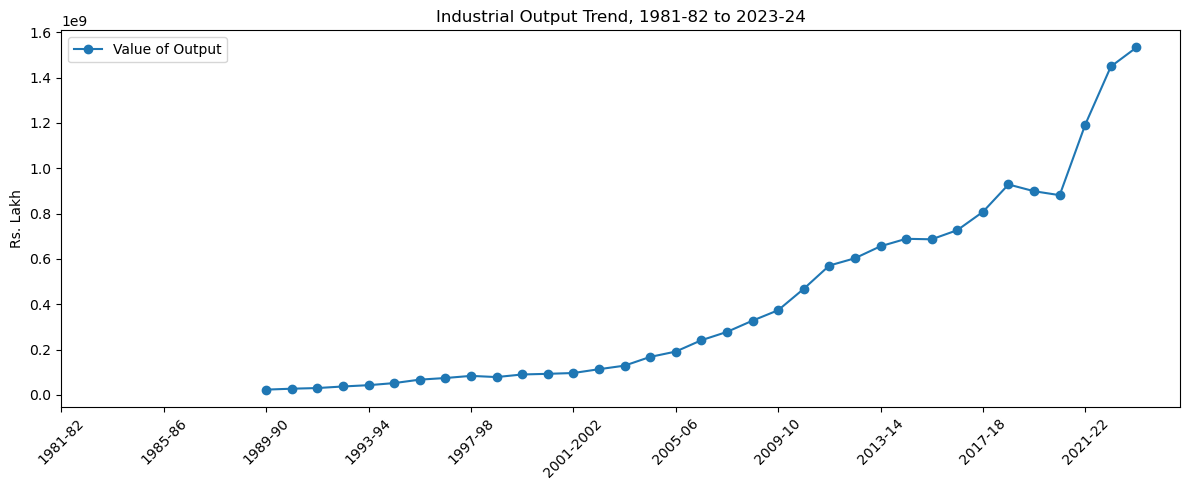

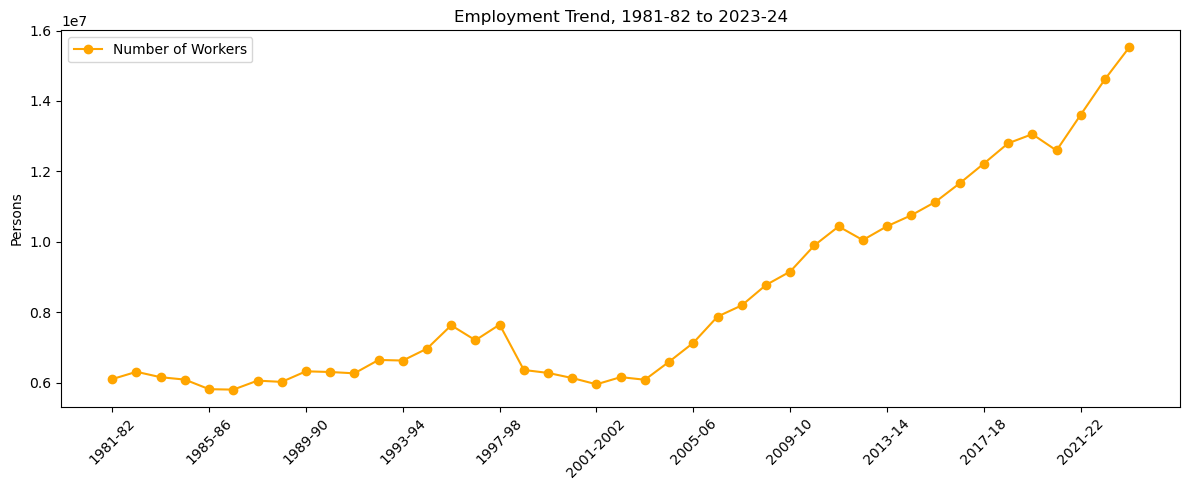

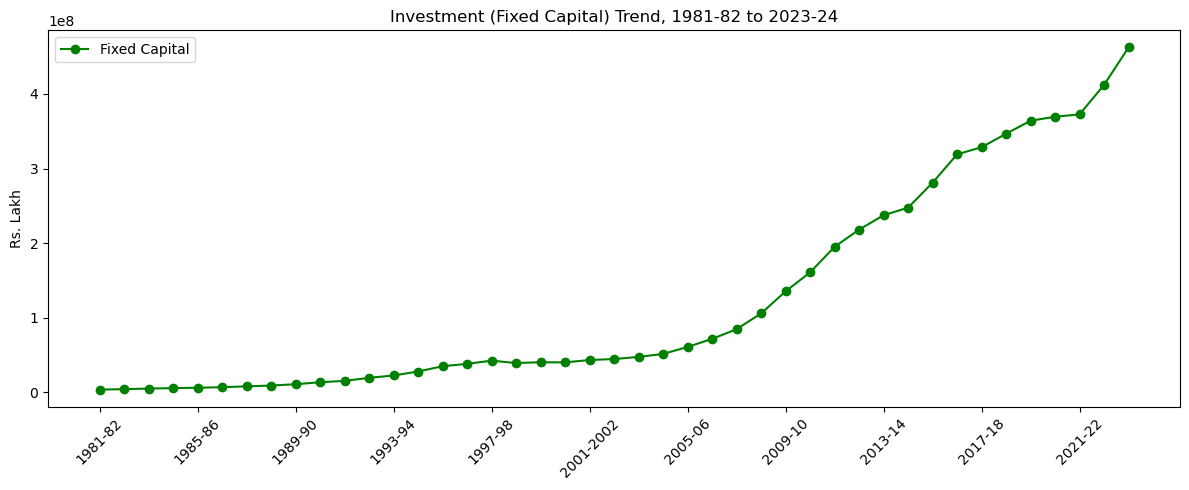

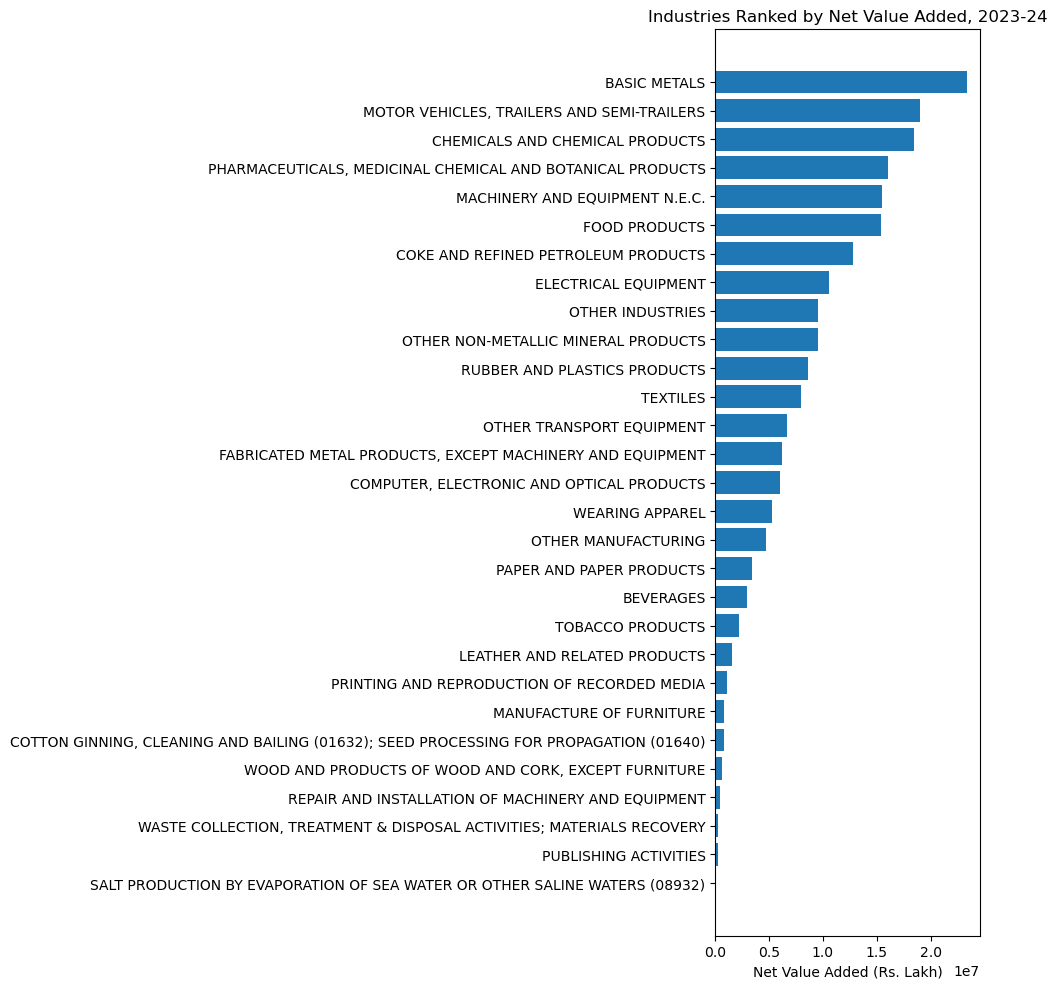


Top 5 industries by Net Value Added:
                                Industry_Description  Net Value Added
0                                       BASIC METALS         23415506
1         MOTOR VEHICLES, TRAILERS AND SEMI-TRAILERS         18970269
2                    CHEMICALS AND CHEMICAL PRODUCTS         18450212
3  PHARMACEUTICALS, MEDICINAL CHEMICAL AND BOTANI...         16077146
4                     MACHINERY AND EQUIPMENT N.E.C.         15468269

Bottom 5 industries by Net Value Added:
                                 Industry_Description  Net Value Added
24  WOOD AND PRODUCTS OF WOOD AND CORK, EXCEPT FUR...           661945
25  REPAIR AND INSTALLATION OF MACHINERY AND EQUIP...           445162
26  WASTE COLLECTION, TREATMENT & DISPOSAL ACTIVIT...           267628
27                              PUBLISHING ACTIVITIES           262369
28  SALT PRODUCTION BY EVAPORATION OF SEA WATER OR...            63692


In [13]:
exec(open("eda_simple.py").read())

Table 1 loaded: (49, 44)
Table 2 loaded: (29, 16)
Table 3 loaded: (36, 15)
Table 5 loaded: (77, 32)

Done. You now have: table1, table2, table3, table5
STUDY OF INDUSTRIAL GROWTH AND PERFORMANCE â€” FULL ANALYSIS

--- PART 1: EDA ---

Table 2 â€” Industry summary stats (2023-24):
       Total Output  Net Value Added    Workers  Fixed Capital
count          29.0             29.0       29.0           29.0
mean     52852297.0        7252218.0   535171.0     15945139.0
std      62260709.0        6689856.0   472166.0     20496908.0
min        308130.0          63692.0     7907.0       117507.0
25%       5589357.0        1122205.0   107228.0      1502001.0
50%      34065248.0        6035708.0   395326.0      7487094.0
75%      56081792.0       10576093.0   851378.0     20721809.0
max     222144598.0       23415506.0  1681312.0     80567152.0

Missing values:
  Table 1: 733 cells
  Table 2: 0 cells
  Table 3: 0 cells
  Table 5: 77 cells

Top 5 industries' share of total NVA: 43.9%
           

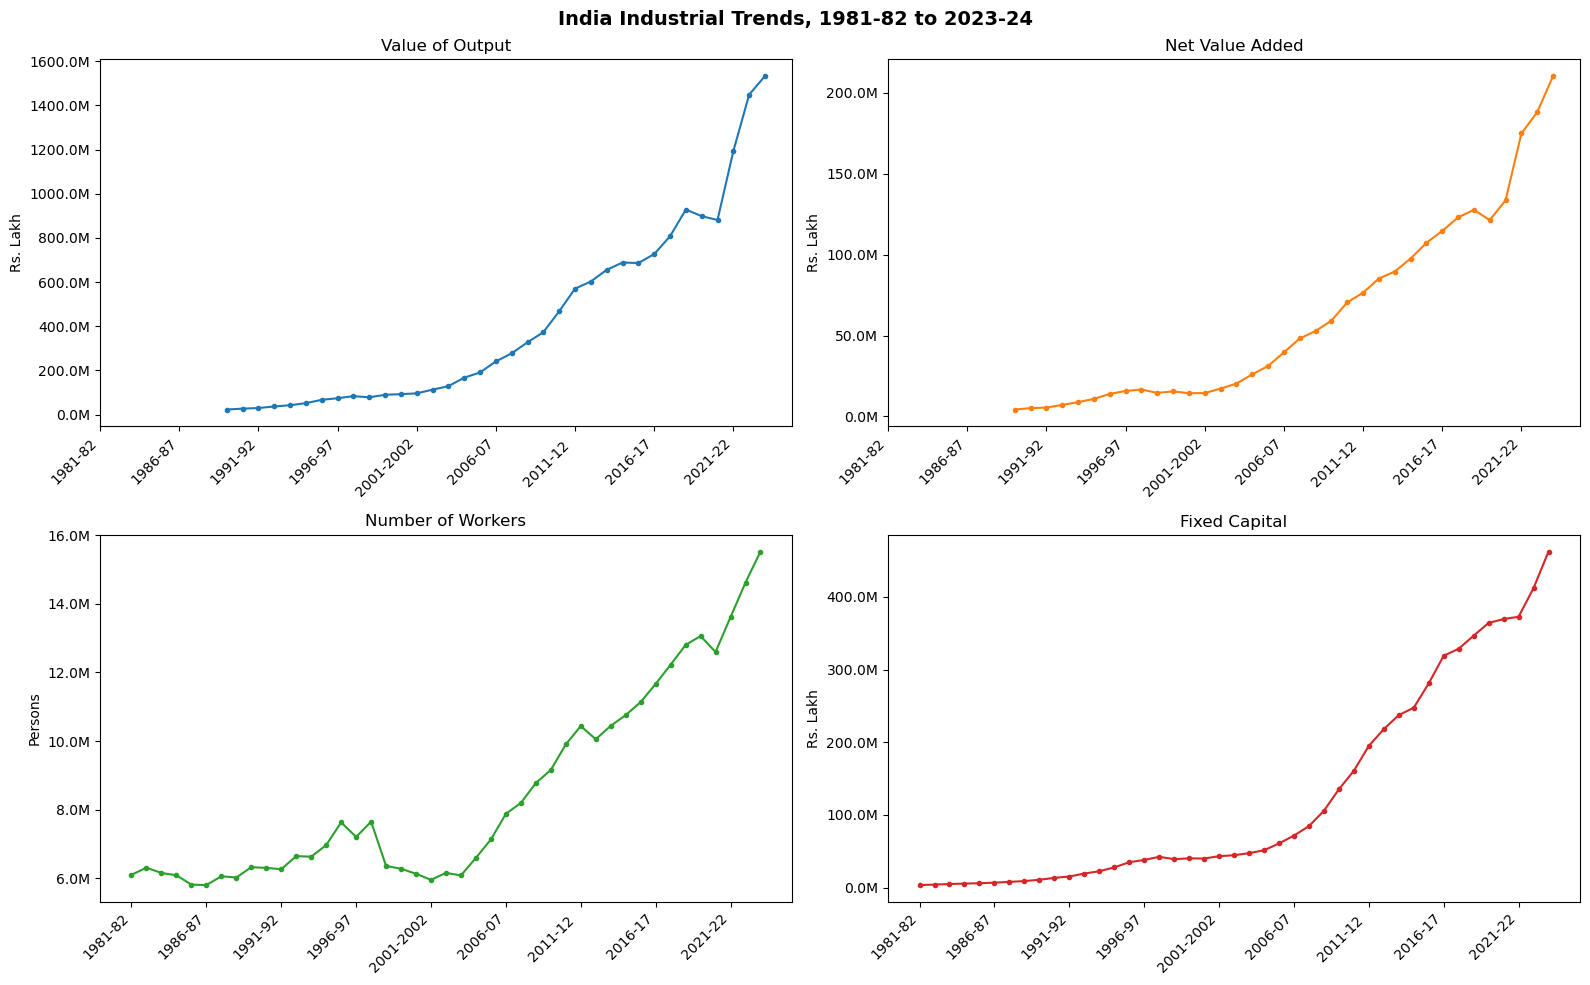

Saved: viz_trends_4panel.png


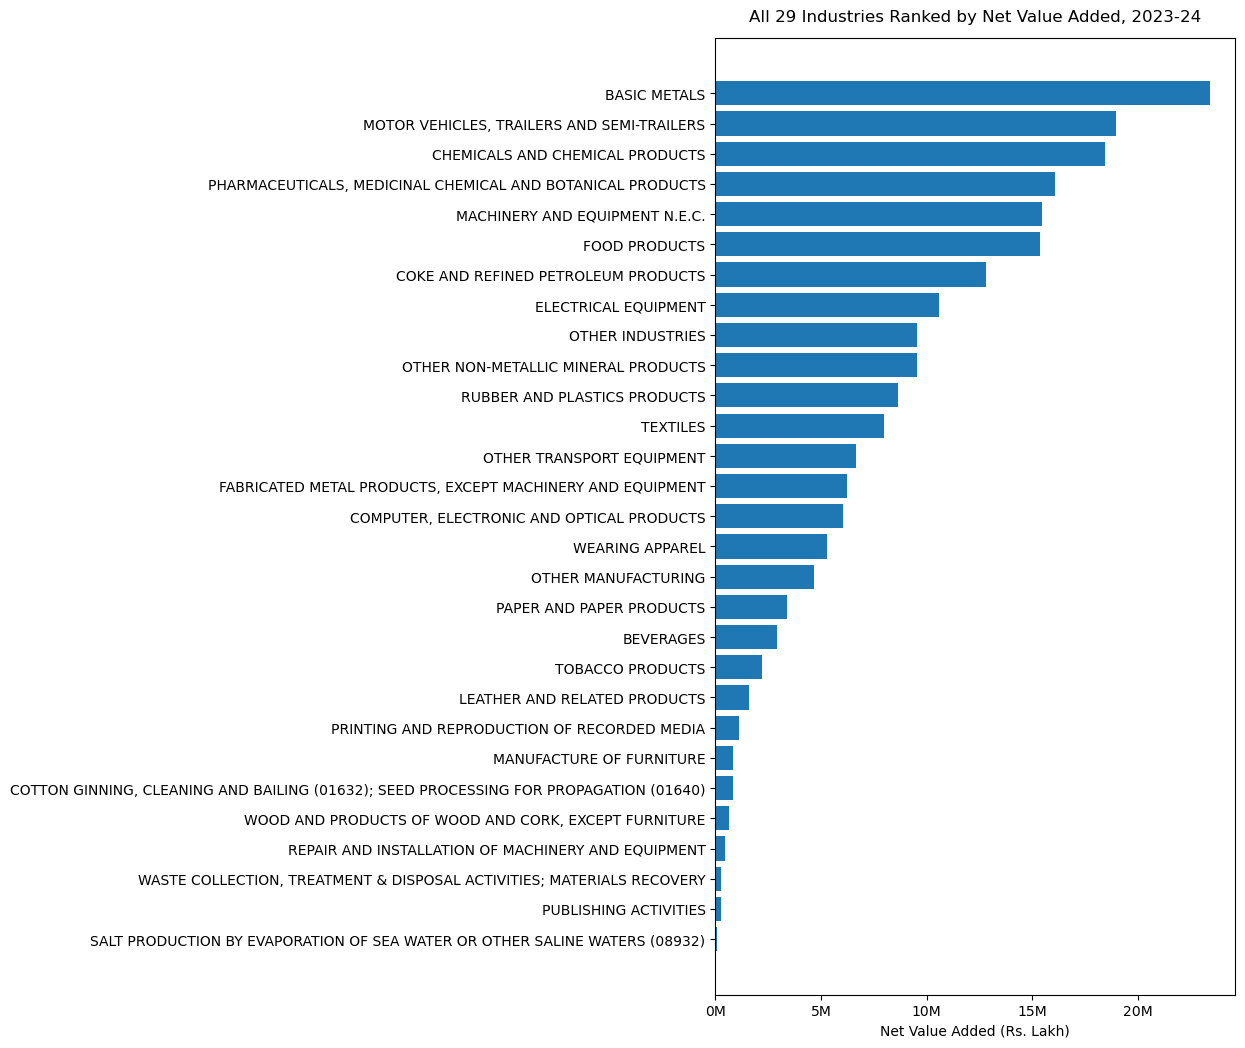

Saved: viz_industry_nva.png


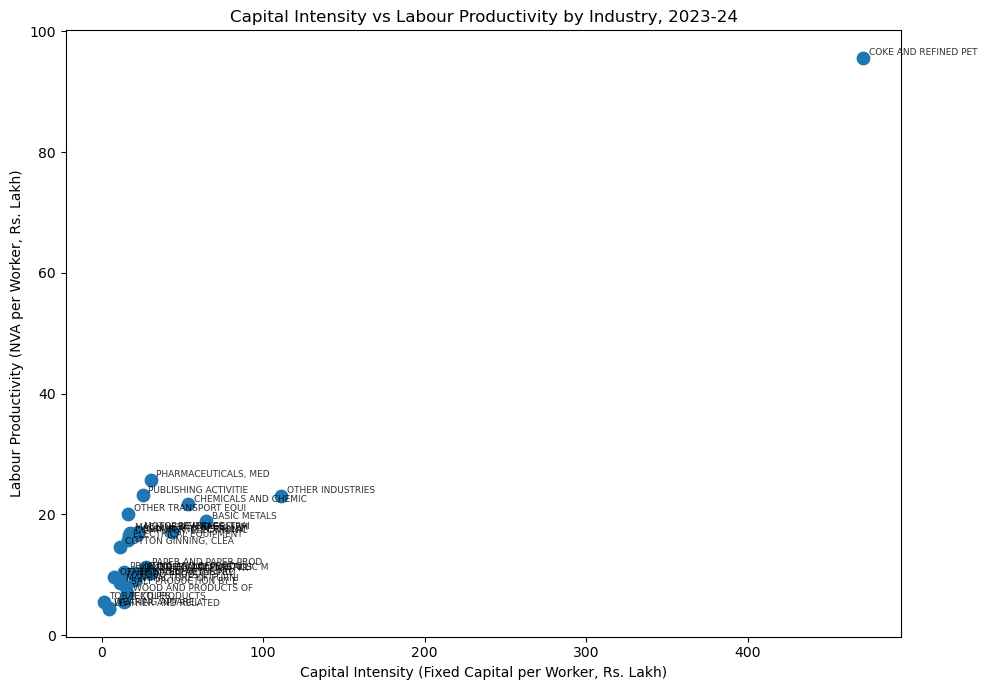

Saved: viz_scatter_productivity.png


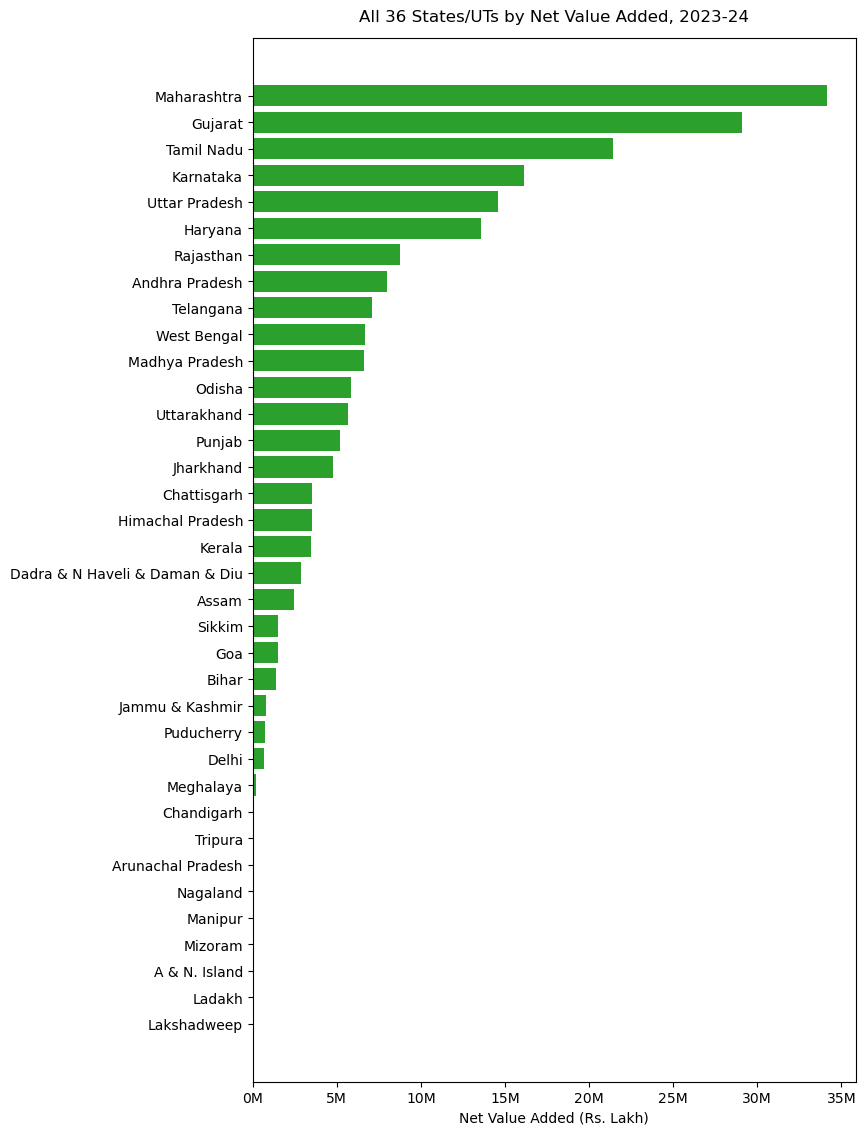

Saved: viz_state_nva.png


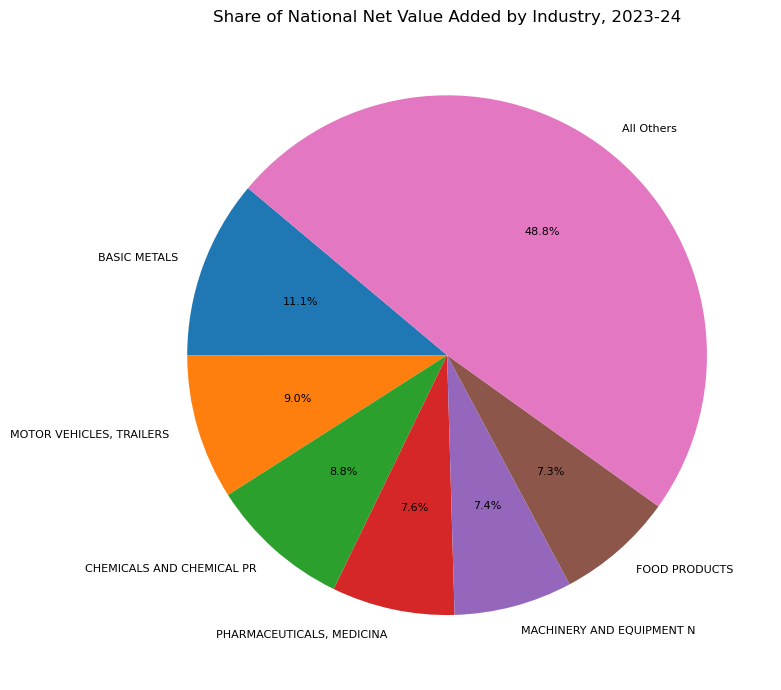

Saved: viz_nva_pie.png

PART 3: INTERPRETATION

OBJECTIVE 1 â€” Production levels across industries (2023-24):
  â€¢ Basic Metals is the top industry by NVA (Rs. 23.4M lakh),
    followed by Motor Vehicles, Chemicals, Pharmaceuticals, and Machinery.
  â€¢ Top 5 industries alone account for 43.9% of
    total industrial Net Value Added â€” high concentration.
  â€¢ Salt Production, Publishing, and Waste Management are the
    smallest contributors (below Rs. 500K lakh NVA each).

OBJECTIVE 2 â€” Trends in output, employment, investment (1981-2024):
  â€¢ Value of Output CAGR: 10.51% per year (nominal)
  â€¢ Net Value Added CAGR: 9.72% per year (nominal)
  â€¢ Fixed Capital CAGR:   12.35% per year (nominal)
  â€¢ Workers CAGR:         2.25% per year
  â†’ Key finding: Output and Capital grew ~4.7x faster
    than employment â€” Indian industry is increasingly capital-
    intensive, not labour-intensive. Growth in output is driven
    by investment, not by hiring more workers.
  â†’ COVI

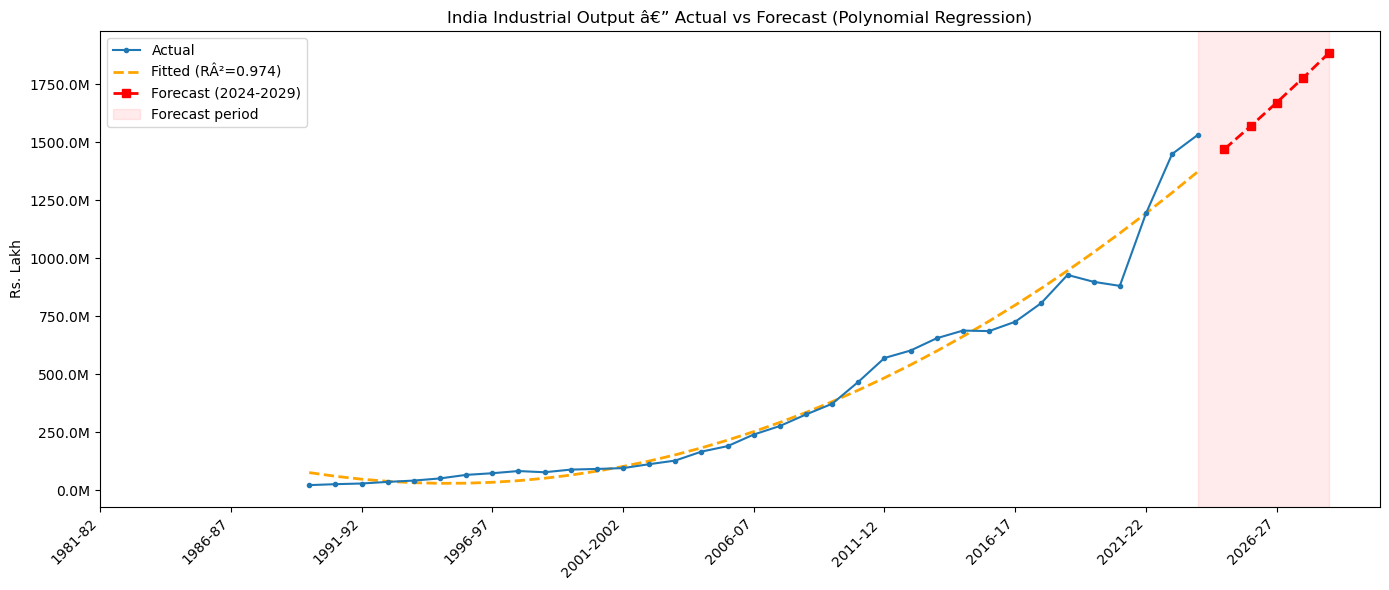

Saved: viz_forecast.png

Model notes:
  â€¢ Polynomial regression (degree 2) fitted on the full 43-year
    series (1981-82 to 2023-24). RÂ² = 0.9738 (excellent fit).
  â€¢ Forecasts are for nominal output only â€” real growth depends
    on inflation trends not modelled here.
  â€¢ The sharp post-COVID recovery (2021-24) inflates the short-
    term forecast upward â€” treat as an upper-bound estimate.
  â€¢ For a more robust model, additional features like GDP growth,
    capital formation, or policy shocks would improve accuracy.
    For this project scope, polynomial trend is appropriate.

ANALYSIS COMPLETE.
Charts saved: viz_trends_4panel.png, viz_industry_nva.png,
              viz_scatter_productivity.png, viz_state_nva.png,
              viz_nva_pie.png, viz_forecast.png


In [14]:
exec(open("full_analysis.py").read())

# MODELING

  ## INDUSTRIAL GROWTH & PERFORMANCE — COMPLETE ML ANALYSIS
  ## Annual Survey of Industries 2023-24, MoSPI
   Three self-contained models: 
   
    MODEL 1 — National Time Series (Table 1, 1989-2024, 35 pts)
              Linear Regression + Polynomial (deg 2)
              Forecast: 2024-25 to 2028-29
 
    MODEL 2 — State Cross-Sectional (Table 3, 36 states)
              Ridge + Random Forest + Gradient Boosting
              Target: Net Value Added
              Output: over/under-performer ranking
 
    MODEL 3 — Sector Cross-Sectional (Table 2, 29 industries)
              Ridge + Random Forest + Gradient Boosting
              Target: Net Value Added
              Output: over/under-performer ranking
 
  Why cross-sectional for states and sectors?
    Tables 2 and 3 are single-year snapshots (2023-24 only).
    A cross-sectional model is the correct and honest choice —
    it reveals which economic inputs drive NVA and which
    states/sectors punch above or below their weight.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")
 
exec(open("load_all_simple.py").read())
 
# clean column names across all tables
table2.columns = [c.strip() for c in table2.columns]
table3.columns = [c.replace("  ", " ").strip() for c in table3.columns]
table5.columns = [str(c).strip() for c in table5.columns]
year_cols = [c for c in table1.columns if c != "characteristic"]
 
print("\n" + "=" * 65)
print("  INDUSTRIAL GROWTH & PERFORMANCE — COMPLETE ML ANALYSIS")
print("  ASI 2023-24, MoSPI")
print("=" * 65)

Table 1 loaded: (49, 44)
Table 2 loaded: (29, 16)
Table 3 loaded: (36, 15)
Table 5 loaded: (77, 32)

Done. You now have: table1, table2, table3, table5

  INDUSTRIAL GROWTH & PERFORMANCE — COMPLETE ML ANALYSIS
  ASI 2023-24, MoSPI


### SHARED UTILITIES

In [16]:
def get_t1_series(keyword):
    """Pull one Table 1 indicator as a clean numeric array."""
    mask = table1["characteristic"].str.contains(keyword, case=False, na=False)
    row  = table1[mask]
    if row.empty:
        return None
    return pd.to_numeric(row[year_cols].iloc[0], errors="coerce").values
 
 
def manual_loo_r2(model, X, y):
    """
    Leave-One-Out Cross-Validation R².
    More reliable than k-fold when n is small (36-77 samples).
    Each observation is held out once as the test point.
    """
    preds = []
    for i in range(len(y)):
        idx_train = [j for j in range(len(y)) if j != i]
        model.fit(X[idx_train], y[idx_train])
        preds.append(model.predict(X[i : i + 1])[0])
    ss_res = np.sum((y - np.array(preds)) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return round(1 - ss_res / ss_tot, 4)
 
 
def cross_section_models(df, label_col, features, target, unit_label):
    """
    Train Ridge, Random Forest, Gradient Boosting on a cross-sectional
    dataset. Returns fitted models, predictions, LOO-CV scores,
    and a results DataFrame with over/under-performer flag.
    """
    df = df[[label_col] + features + [target]].dropna().reset_index(drop=True)
    X_raw = df[features].values
    y     = df[target].values
    sc    = StandardScaler()
    X     = sc.fit_transform(X_raw)
 
    # --- train ---
    ridge = Ridge(alpha=10)
    rf    = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
    gb    = GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                      learning_rate=0.05, random_state=42)
 
    ridge.fit(X, y);  rf.fit(X, y);  gb.fit(X, y)
 
    y_pred_ridge = ridge.predict(X)
    y_pred_rf    = rf.predict(X)
    y_pred_gb    = gb.predict(X)
 
    # --- LOO-CV ---
    loo_ridge = manual_loo_r2(Ridge(alpha=10), X, y)
    loo_rf    = manual_loo_r2(
        RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42), X, y)
    loo_gb    = manual_loo_r2(
        GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                  learning_rate=0.05, random_state=42), X, y)
 
    # --- metrics table ---
    metrics = pd.DataFrame([
        {"Model": "Ridge Regression",
         "R² in-sample": round(r2_score(y, y_pred_ridge), 4),
         "R² LOO-CV":    loo_ridge,
         "MAE":          f"{mean_absolute_error(y, y_pred_ridge):,.0f}"},
        {"Model": "Random Forest",
         "R² in-sample": round(r2_score(y, y_pred_rf), 4),
         "R² LOO-CV":    loo_rf,
         "MAE":          f"{mean_absolute_error(y, y_pred_rf):,.0f}"},
        {"Model": "Gradient Boosting",
         "R² in-sample": round(r2_score(y, y_pred_gb), 4),
         "R² LOO-CV":    loo_gb,
         "MAE":          f"{mean_absolute_error(y, y_pred_gb):,.0f}"},
    ])
 
    # use best LOO-CV model for the residual analysis
    best_pred = max(
        [(y_pred_ridge, loo_ridge, "Ridge"),
         (y_pred_rf,    loo_rf,    "Random Forest"),
         (y_pred_gb,    loo_gb,    "Gradient Boosting")],
        key=lambda x: x[1]
    )
    y_best, best_name = best_pred[0], best_pred[2]
 
    df["Predicted"] = y_best
    df["Residual"]  = df[target] - df["Predicted"]
    df["Status"]    = np.where(df["Residual"] > 0, "Over-performer", "Under-performer")
 
    # feature importance from GB (more stable than RF for small n)
    fi = pd.DataFrame({
        "Feature":      features,
        "RF Importance": rf.feature_importances_,
        "GB Importance": gb.feature_importances_,
    }).sort_values("GB Importance", ascending=False).reset_index(drop=True)
 
    return df, metrics, fi, best_name, y, y_best, loo_ridge, loo_rf, loo_gb

# MODEL 1 — NATIONAL TIME SERIES + FORECAST

In [17]:
print("\n" + "─" * 65)
print("  MODEL 1: NATIONAL TIME SERIES (Table 1, 1989-2024)")
print("─" * 65)
 
output_vals  = get_t1_series("VALUE OF OUTPUT")
nva_vals     = get_t1_series("NET VALUE ADDED")
worker_vals  = get_t1_series("NUMBER OF WORKERS")
capital_vals = get_t1_series("FIXED  CAPITAL")
 
df_ts = pd.DataFrame({
    "Year_Label":    year_cols,
    "Year_Index":    np.arange(len(year_cols)),
    "Output":        output_vals,
    "NVA":           nva_vals,
    "Fixed_Capital": capital_vals,
    "Workers":       worker_vals,
}).dropna().reset_index(drop=True)
 
print(f"  Dataset: {len(df_ts)} years "
      f"({df_ts['Year_Label'].iloc[0]} → {df_ts['Year_Label'].iloc[-1]})")
 
X_ts  = df_ts[["Year_Index", "Fixed_Capital", "Workers"]].values
y_ts  = df_ts["Output"].values
sc_ts = StandardScaler()
X_tss = sc_ts.fit_transform(X_ts)
 
# Linear Regression
lr = LinearRegression()
lr.fit(X_tss, y_ts)
y_lr = lr.predict(X_tss)
 
# Polynomial deg-2
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_tss)
pr     = LinearRegression()
pr.fit(X_poly, y_ts)
y_pr = pr.predict(X_poly)
 
print(f"\n  Linear Regression R²   : {r2_score(y_ts, y_lr):.4f}")
print(f"  Polynomial (deg 2) R²  : {r2_score(y_ts, y_pr):.4f}")
print(f"  → Polynomial used for forecasting (higher R², captures curve)")
 
# Forecast 2024-25 to 2028-29
cap_gr = (df_ts["Fixed_Capital"].iloc[-1] / df_ts["Fixed_Capital"].iloc[-5]) ** (1/4) - 1
wrk_gr = (df_ts["Workers"].iloc[-1]       / df_ts["Workers"].iloc[-5])       ** (1/4) - 1
start  = int(df_ts["Year_Label"].iloc[-1].split("-")[0])
last_i = df_ts["Year_Index"].iloc[-1]
last_c = df_ts["Fixed_Capital"].iloc[-1]
last_w = df_ts["Workers"].iloc[-1]
 
df_fc = pd.DataFrame([{
    "Year_Label":    f"{start+i}-{str(start+i+1)[-2:]}",
    "Year_Index":    last_i + i,
    "Fixed_Capital": last_c * (1 + cap_gr) ** i,
    "Workers":       last_w * (1 + wrk_gr) ** i,
} for i in range(1, 6)])
 
X_fc   = sc_ts.transform(df_fc[["Year_Index", "Fixed_Capital", "Workers"]].values)
X_fc_p = poly.transform(X_fc)
df_fc["Forecast_LR"] = lr.predict(X_fc)
df_fc["Forecast_PR"] = pr.predict(X_fc_p)
 
print("\n  5-Year National Output Forecast (Rs. Lakh):")
print(f"  {'Year':<12} {'Linear Reg':>18} {'Polynomial':>18}")
print("  " + "─" * 50)
for _, r in df_fc.iterrows():
    print(f"  {r['Year_Label']:<12} {r['Forecast_LR']:>18,.0f} {r['Forecast_PR']:>18,.0f}")


─────────────────────────────────────────────────────────────────
  MODEL 1: NATIONAL TIME SERIES (Table 1, 1989-2024)
─────────────────────────────────────────────────────────────────
  Dataset: 35 years (1989-90 → 2023-24)

  Linear Regression R²   : 0.9658
  Polynomial (deg 2) R²  : 0.9954
  → Polynomial used for forecasting (higher R², captures curve)

  5-Year National Output Forecast (Rs. Lakh):
  Year                 Linear Reg         Polynomial
  ──────────────────────────────────────────────────
  2024-25           1,436,975,832      1,667,731,437
  2025-26           1,531,347,761      1,832,949,940
  2026-27           1,630,412,975      2,010,074,543
  2027-28           1,734,418,993      2,199,411,020
  2028-29           1,843,626,741      2,401,084,574


# MODEL 2 — STATE CROSS-SECTIONAL (36 states)

In [18]:
print("\n" + "─" * 65)
print("  MODEL 2: STATE CROSS-SECTIONAL (Table 3, 36 states)")
print("─" * 65)
 
STATE_FEATS  = ["Fixed Capital", "Workers", "Total Input", "Factories"]
STATE_TARGET = "Net Value Added"
 
df_state, state_metrics, state_fi, state_best, y_state, yp_state, \
    loo_s_ridge, loo_s_rf, loo_s_gb = cross_section_models(
        table3.copy(), "State", STATE_FEATS, STATE_TARGET, "state")
 
print(f"\n  Samples: {len(df_state)} states/UTs")
print(f"\n  Model Performance:")
print(state_metrics.to_string(index=False))
print(f"\n  Best model (LOO-CV): {state_best}")
 
print(f"\n  All 36 States — Actual vs Predicted NVA ({state_best}):")
df_ss = df_state.sort_values("Net Value Added", ascending=False).reset_index(drop=True)
df_ss.index += 1
print(f"  {'Rank':<5} {'State':<35} {'Actual NVA':>14} {'Predicted':>14} {'Gap':>12} Status")
print("  " + "─" * 85)
for i, r in df_ss.iterrows():
    gap = f"+{r['Residual']:,.0f}" if r["Residual"] > 0 else f"{r['Residual']:,.0f}"
    print(f"  {i:<5} {r['State']:<35} {r['Net Value Added']:>14,.0f} "
          f"{r['Predicted']:>14,.0f} {gap:>12}  {r['Status']}")


─────────────────────────────────────────────────────────────────
  MODEL 2: STATE CROSS-SECTIONAL (Table 3, 36 states)
─────────────────────────────────────────────────────────────────

  Samples: 36 states/UTs

  Model Performance:
            Model  R² in-sample  R² LOO-CV       MAE
 Ridge Regression        0.9344     0.9007 1,207,788
    Random Forest        0.9900     0.9186   424,262
Gradient Boosting        1.0000     0.9301     4,761

  Best model (LOO-CV): Gradient Boosting

  All 36 States — Actual vs Predicted NVA (Gradient Boosting):
  Rank  State                                   Actual NVA      Predicted          Gap Status
  ─────────────────────────────────────────────────────────────────────────────────────
  1     Maharashtra                             34,145,981     34,140,214       +5,767  Over-performer
  2     Gujarat                                 29,099,304     29,098,716         +588  Over-performer
  3     Tamil Nadu                              21,395,650 

# MODEL 3 — SECTOR CROSS-SECTIONAL (29 industries)

In [19]:
print("\n" + "─" * 65)
print("  MODEL 3: SECTOR CROSS-SECTIONAL (Table 2, 29 industries)")
print("─" * 65)
 
SECTOR_FEATS  = ["Fixed Capital", "Workers", "Total Input", "Factories"]
SECTOR_TARGET = "Net Value Added"
 
df_sect, sect_metrics, sect_fi, sect_best, y_sect, yp_sect, \
    loo_t_ridge, loo_t_rf, loo_t_gb = cross_section_models(
        table2.copy(), "Industry_Description", SECTOR_FEATS, SECTOR_TARGET, "sector")
 
print(f"\n  Samples: {len(df_sect)} industry groups")
print(f"\n  Model Performance:")
print(sect_metrics.to_string(index=False))
print(f"\n  Best model (LOO-CV): {sect_best}")
 
print(f"\n  All 29 Sectors — Actual vs Predicted NVA ({sect_best}):")
df_se = df_sect.sort_values("Net Value Added", ascending=False).reset_index(drop=True)
df_se.index += 1
print(f"  {'Rank':<5} {'Industry':<50} {'Actual NVA':>14} {'Predicted':>14} {'Gap':>12} Status")
print("  " + "─" * 100)
for i, r in df_se.iterrows():
    gap = f"+{r['Residual']:,.0f}" if r["Residual"] > 0 else f"{r['Residual']:,.0f}"
    name = r["Industry_Description"][:48]
    print(f"  {i:<5} {name:<50} {r['Net Value Added']:>14,.0f} "
          f"{r['Predicted']:>14,.0f} {gap:>12}  {r['Status']}")
 


─────────────────────────────────────────────────────────────────
  MODEL 3: SECTOR CROSS-SECTIONAL (Table 2, 29 industries)
─────────────────────────────────────────────────────────────────

  Samples: 29 industry groups

  Model Performance:
            Model  R² in-sample  R² LOO-CV       MAE
 Ridge Regression        0.7989     0.7408 2,232,024
    Random Forest        0.9763     0.8151   683,684
Gradient Boosting        1.0000     0.7968     1,756

  Best model (LOO-CV): Random Forest

  All 29 Sectors — Actual vs Predicted NVA (Random Forest):
  Rank  Industry                                               Actual NVA      Predicted          Gap Status
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  1     BASIC METALS                                           23,415,506     21,094,413   +2,321,093  Over-performer
  2     MOTOR VEHICLES, TRAILERS AND SEMI-TRAILERS             18,970,269     17,934,054   +1,036,215  Over-perfor

# MASTER VISUALISATION — 3 rows × 2 cols = 6 panels

In [20]:
print("\nGenerating master visualisation...")
 
C = {
    "actual":  "#2c3e50",
    "lr":      "#3498db",
    "pr":      "#e67e22",
    "over":    "#27ae60",
    "under":   "#e74c3c",
    "rf":      "#3498db",
    "gb":      "#9b59b6",
    "ridge":   "#1abc9c",
    "shade":   "#e74c3c",
    "bg":      "#f7f9fc",
    "panel":   "#ffffff",
}
 
fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor(C["bg"])
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
 
# ── helper: spine cleanup ─────────────────────────────────────────────
def clean_ax(ax):
    ax.set_facecolor(C["panel"])
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.22, linestyle="--", color="#aaa")


Generating master visualisation...


<Figure size 2200x2600 with 0 Axes>

# PANEL 1 (top-left): National time series — actual vs fitted

In [21]:
ax1 = fig.add_subplot(gs[0, 0])
clean_ax(ax1)
ax1.set_title("Panel 1 — National Output: Actual vs Fitted\n(1989-90 to 2023-24)",
              fontsize=11, fontweight="bold", pad=8)
 
ax1.plot(df_ts["Year_Label"], y_ts / 1e6,
         "o-", color=C["actual"], lw=2, ms=4, label="Actual", zorder=5)
ax1.plot(df_ts["Year_Label"], y_lr / 1e6,
         "--", color=C["lr"], lw=1.8,
         label=f"Linear  R²={r2_score(y_ts,y_lr):.3f}")
ax1.plot(df_ts["Year_Label"], y_pr / 1e6,
         "--", color=C["pr"], lw=1.8,
         label=f"Poly-2  R²={r2_score(y_ts,y_pr):.3f}")
 
ticks = df_ts["Year_Label"].tolist()[::5]
ax1.set_xticks(ticks)
ax1.set_xticklabels(ticks, rotation=45, ha="right", fontsize=7.5)
ax1.set_ylabel("Value of Output (Million Rs. Lakh)", fontsize=9)
ax1.legend(fontsize=8.5, framealpha=0.9)

# PANEL 2 (top-right): National 5-year forecast

In [22]:
ax2 = fig.add_subplot(gs[0, 1])
clean_ax(ax2)
ax2.set_title("Panel 2 — National Output: 5-Year Forecast\n(2024-25 to 2028-29)",
              fontsize=11, fontweight="bold", pad=8)
 
hist_n   = 12
x_hist   = df_ts["Year_Label"].tolist()[-hist_n:]
y_hist   = (y_ts[-hist_n:] / 1e6).tolist()
x_fcast  = df_fc["Year_Label"].tolist()
 
ax2.plot(x_hist, y_hist, "o-", color=C["actual"], lw=2, ms=5,
         label="Actual", zorder=5)
ax2.plot(x_hist[-1:] + x_fcast,
         [y_hist[-1]] + (df_fc["Forecast_LR"] / 1e6).tolist(),
         "s--", color=C["lr"], ms=6, lw=1.8, label="Linear Reg")
ax2.plot(x_hist[-1:] + x_fcast,
         [y_hist[-1]] + (df_fc["Forecast_PR"] / 1e6).tolist(),
         "s--", color=C["pr"], ms=6, lw=1.8, label="Polynomial")
 
ax2.axvspan(x_hist[-1], x_fcast[-1], alpha=0.07, color=C["shade"])
ax2.text(x_fcast[2], ax2.get_ylim()[0] * 1.02, "← Forecast period",
         fontsize=7.5, color=C["shade"])
all_x2 = x_hist[::3] + x_fcast
ax2.set_xticks(all_x2)
ax2.set_xticklabels(all_x2, rotation=45, ha="right", fontsize=7.5)
ax2.set_ylabel("Value of Output (Million Rs. Lakh)", fontsize=9)
ax2.legend(fontsize=8.5, framealpha=0.9)


# PANEL 3 (mid-left): All 36 states — actual vs predicted NVA

In [23]:

ax3 = fig.add_subplot(gs[1, 0])
clean_ax(ax3)
ax3.set_title(f"Panel 3 — All 36 States: Actual vs Predicted NVA\n"
              f"(Best model: {state_best}, LOO-CV R²="
              f"{max(loo_s_ridge, loo_s_rf, loo_s_gb):.4f})",
              fontsize=11, fontweight="bold", pad=8)
 
x3     = np.arange(len(df_ss))
labels3 = df_ss["State"].tolist()
ax3.bar(x3 - 0.22, df_ss["Net Value Added"]  / 1e6, 0.42,
        color=C["actual"], alpha=0.85, label="Actual NVA")
ax3.bar(x3 + 0.22, df_ss["Predicted"] / 1e6, 0.42,
        color=C["pr"],     alpha=0.85, label="Predicted NVA")
ax3.set_xticks(x3)
ax3.set_xticklabels(labels3, rotation=60, ha="right", fontsize=6.2)
ax3.set_ylabel("Net Value Added (Million Rs. Lakh)", fontsize=9)
ax3.legend(fontsize=8.5, framealpha=0.9)
 

# PANEL 4 (mid-right): State over/under-performer residual chart

In [24]:

ax4 = fig.add_subplot(gs[1, 1])
clean_ax(ax4)
ax4.set_title("Panel 4 — State Over/Under-Performers\n"
              "(Actual − Predicted NVA, sorted)",
              fontsize=11, fontweight="bold", pad=8)
ax4.grid(axis="x", alpha=0.22, linestyle="--", color="#aaa")
ax4.grid(axis="y", alpha=0)
 
df_res4  = df_state.sort_values("Residual").reset_index(drop=True)
cols4    = [C["over"] if r > 0 else C["under"] for r in df_res4["Residual"]]
ax4.barh(df_res4["State"], df_res4["Residual"] / 1e6, color=cols4, alpha=0.85)
ax4.axvline(0, color="black", lw=0.9, ls="--")
ax4.set_xlabel("Residual = Actual − Predicted (Million Rs. Lakh)", fontsize=9)
ax4.tick_params(axis="y", labelsize=7)
ax4.legend(handles=[
    mpatches.Patch(color=C["over"],  label="Over-performer"),
    mpatches.Patch(color=C["under"], label="Under-performer"),
], fontsize=8.5, loc="lower right", framealpha=0.9)

# PANEL 5 (bottom-left): All 29 sectors — actual vs predicted NVA

In [25]:
ax5 = fig.add_subplot(gs[2, 0])
clean_ax(ax5)
ax5.set_title(f"Panel 5 — All 29 Sectors: Actual vs Predicted NVA\n"
              f"(Best model: {sect_best}, LOO-CV R²="
              f"{max(loo_t_ridge, loo_t_rf, loo_t_gb):.4f})",
              fontsize=11, fontweight="bold", pad=8)
 
x5      = np.arange(len(df_se))
labels5 = [s[:22] for s in df_se["Industry_Description"].tolist()]
ax5.bar(x5 - 0.22, df_se["Net Value Added"] / 1e6, 0.42,
        color=C["actual"], alpha=0.85, label="Actual NVA")
ax5.bar(x5 + 0.22, df_se["Predicted"] / 1e6, 0.42,
        color=C["gb"],     alpha=0.85, label="Predicted NVA")
ax5.set_xticks(x5)
ax5.set_xticklabels(labels5, rotation=60, ha="right", fontsize=6.5)
ax5.set_ylabel("Net Value Added (Million Rs. Lakh)", fontsize=9)
ax5.legend(fontsize=8.5, framealpha=0.9)

# PANEL 6 (bottom-right): Sector over/under-performer residual chart

In [26]:
ax6 = fig.add_subplot(gs[2, 1])
clean_ax(ax6)
ax6.set_title("Panel 6 — Sector Over/Under-Performers\n"
              "(Actual − Predicted NVA, sorted)",
              fontsize=11, fontweight="bold", pad=8)
ax6.grid(axis="x", alpha=0.22, linestyle="--", color="#aaa")
ax6.grid(axis="y", alpha=0)
 
df_res6 = df_sect.sort_values("Residual").reset_index(drop=True)
cols6   = [C["over"] if r > 0 else C["under"] for r in df_res6["Residual"]]
short   = [s[:30] for s in df_res6["Industry_Description"]]
ax6.barh(short, df_res6["Residual"] / 1e6, color=cols6, alpha=0.85)
ax6.axvline(0, color="black", lw=0.9, ls="--")
ax6.set_xlabel("Residual = Actual − Predicted (Million Rs. Lakh)", fontsize=9)
ax6.tick_params(axis="y", labelsize=7.2)
ax6.legend(handles=[
    mpatches.Patch(color=C["over"],  label="Over-performer"),
    mpatches.Patch(color=C["under"], label="Under-performer"),
], fontsize=8.5, loc="lower right", framealpha=0.9)

# ── Title + footer ──────

In [27]:
fig.suptitle(
    "Industrial Growth & Performance — Complete ML Analysis\n"
    "Study of Industrial Growth and Performance  |  ASI 2023-24, MoSPI",
    fontsize=15, fontweight="bold", y=1.01)
 
fig.text(0.5, 0.002,
         "Source: ASI 2023-24, MoSPI  |  "
         "Models: Linear Reg, Polynomial Reg, Ridge, Random Forest, Gradient Boosting  |  "
         "Validation: LOO-CV (Leave-One-Out Cross-Validation)",
         ha="center", fontsize=7.5, color="#666")
 
plt.savefig("ml_complete.png", dpi=140, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

print("Saved: ml_complete.png")

<Figure size 640x480 with 0 Axes>

Saved: ml_complete.png


# FEATURE IMPORTANCE CHART — states vs sectors side by side

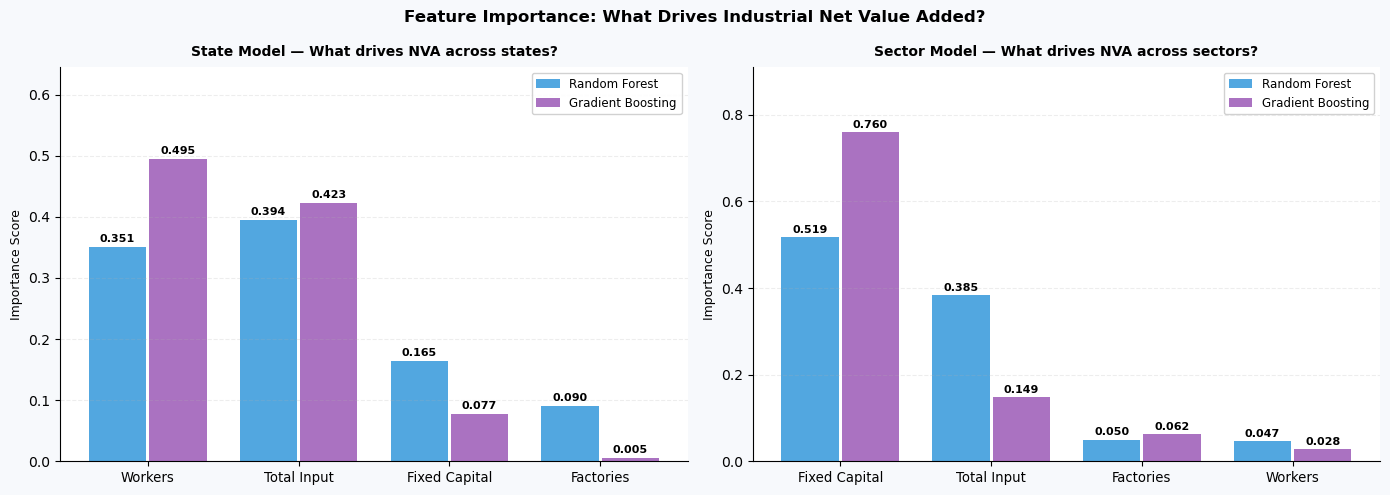

Saved: ml_feature_importance.png


In [28]:
fig2, (fa, fb) = plt.subplots(1, 2, figsize=(14, 5))
fig2.patch.set_facecolor(C["bg"])
 
for ax, fi_df, title in [
    (fa, state_fi, "State Model — What drives NVA across states?"),
    (fb, sect_fi,  "Sector Model — What drives NVA across sectors?"),
]:
    ax.set_facecolor(C["panel"])
    x = np.arange(len(fi_df))
    b1 = ax.bar(x - 0.2, fi_df["RF Importance"], 0.38,
                color=C["rf"], alpha=0.85, label="Random Forest")
    b2 = ax.bar(x + 0.2, fi_df["GB Importance"], 0.38,
                color=C["gb"], alpha=0.85, label="Gradient Boosting")
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(fi_df["Feature"], fontsize=9.5)
    ax.set_ylabel("Importance Score", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.set_ylim(0, fi_df[["RF Importance", "GB Importance"]].max().max() + 0.15)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.22, linestyle="--")
 
fig2.suptitle("Feature Importance: What Drives Industrial Net Value Added?",
              fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("ml_feature_importance.png", dpi=140, bbox_inches="tight",
            facecolor=fig2.get_facecolor())
plt.show()
print("Saved: ml_feature_importance.png")

# CORRELATION HEATMAP — Feature Relationships


─────────────────────────────────────────────────────────────────
  CORRELATION HEATMAP — State & Sector Drivers of NVA
─────────────────────────────────────────────────────────────────


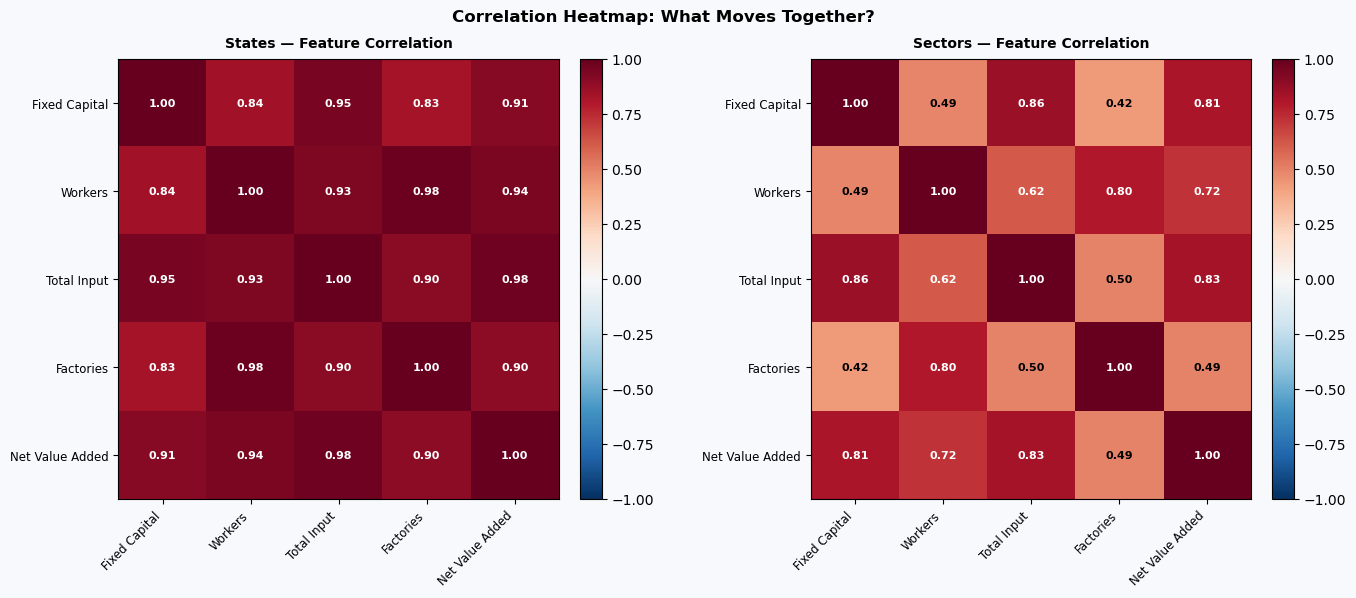

Saved: correlation_heatmap.png


In [29]:
print("\n" + "─" * 65)
print("  CORRELATION HEATMAP — State & Sector Drivers of NVA")
print("─" * 65)

corr_cols = STATE_FEATS + [STATE_TARGET]
corr_state = df_state[corr_cols].corr()
corr_sect  = df_sect[corr_cols].corr()

fig3, (ca, cb) = plt.subplots(1, 2, figsize=(14, 6))
fig3.patch.set_facecolor(C["bg"])

for ax, corr, title in [(ca, corr_state, "States — Feature Correlation"),
                         (cb, corr_sect,  "Sectors — Feature Correlation")]:
    ax.set_facecolor(C["panel"])
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8.5)
    ax.set_yticklabels(corr.columns, fontsize=8.5)
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="white" if abs(val) > 0.6 else "black")
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    fig3.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig3.suptitle("Correlation Heatmap: What Moves Together?", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=140, bbox_inches="tight", facecolor=fig3.get_facecolor())
plt.show()
print("Saved: correlation_heatmap.png")

# PRODUCTIVITY & EFFICIENCY RATIOS

In [30]:
print("\n" + "─" * 65)
print("  PRODUCTIVITY & EFFICIENCY RATIOS")
print("─" * 65)

def add_efficiency_ratios(df):
    out = df.copy()
    out["NVA_per_Worker"]     = out[STATE_TARGET] / out["Workers"]
    out["NVA_per_Capital"]    = out[STATE_TARGET] / out["Fixed Capital"]
    out["NVA_per_Factory"]    = out[STATE_TARGET] / out["Factories"]
    out["Input_Efficiency"]   = out[STATE_TARGET] / out["Total Input"]
    out["Capital_per_Worker"] = out["Fixed Capital"] / out["Workers"]
    return out

df_state_eff = add_efficiency_ratios(df_state)
df_sect_eff  = add_efficiency_ratios(df_sect)

print("\n  Top 10 States by NVA per Worker (labor productivity):")
top_state_eff = df_state_eff.sort_values("NVA_per_Worker", ascending=False).head(10)
print(top_state_eff[["State", "NVA_per_Worker", "Capital_per_Worker", "Input_Efficiency"]]
      .to_string(index=False))

print("\n  Top 10 Sectors by NVA per Worker (labor productivity):")
top_sect_eff = df_sect_eff.sort_values("NVA_per_Worker", ascending=False).head(10)
print(top_sect_eff[["Industry_Description", "NVA_per_Worker", "Capital_per_Worker", "Input_Efficiency"]]
      .to_string(index=False))

print("\n  Bottom 5 States by NVA per Worker (lowest labor productivity):")
print(df_state_eff.sort_values("NVA_per_Worker").head(5)[["State", "NVA_per_Worker"]].to_string(index=False))


─────────────────────────────────────────────────────────────────
  PRODUCTIVITY & EFFICIENCY RATIOS
─────────────────────────────────────────────────────────────────

  Top 10 States by NVA per Worker (labor productivity):
           State  NVA_per_Worker  Capital_per_Worker  Input_Efficiency
          Sikkim       73.418487           25.224202          0.963481
       Jharkhand       24.999471           55.819813          0.230759
             Goa       22.326196           26.912785          0.280789
Himachal Pradesh       20.501288           28.620459          0.285342
          Odisha       18.614050          117.194502          0.131648
     Maharashtra       18.460949           29.859511          0.186957
  Madhya Pradesh       17.125372           63.190397          0.178526
      Puducherry       16.957765           16.547940          0.230510
       Karnataka       16.677572           29.140376          0.201528
     Uttarakhand       16.048092           18.030982          0.2

# CONCENTRATION ANALYSIS — Herfindahl-Hirschman Index (HHI)


─────────────────────────────────────────────────────────────────
  CONCENTRATION ANALYSIS — HHI
─────────────────────────────────────────────────────────────────

  States (NVA concentration): HHI = 810  ->  Unconcentrated (competitive)
  Top 5 share of national NVA: 54.9%

  Sectors (NVA concentration): HHI = 628  ->  Unconcentrated (competitive)
  Top 5 share of national NVA: 43.9%


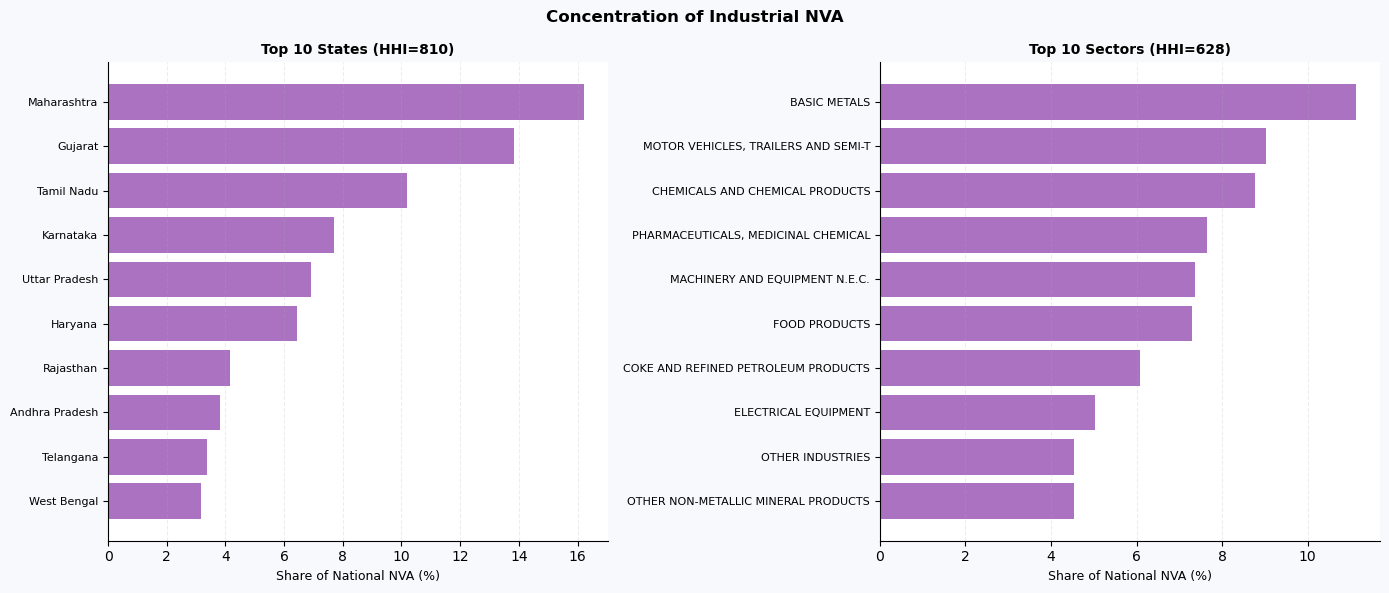


Saved: hhi_concentration.png


In [31]:
print("\n" + "─" * 65)
print("  CONCENTRATION ANALYSIS — HHI")
print("─" * 65)

def compute_hhi(df, value_col, label):
    shares = df[value_col] / df[value_col].sum() * 100
    hhi = (shares ** 2).sum()
    if hhi < 1500:
        level = "Unconcentrated (competitive)"
    elif hhi < 2500:
        level = "Moderately concentrated"
    else:
        level = "Highly concentrated"
    print(f"\n  {label}: HHI = {hhi:,.0f}  ->  {level}")
    top5 = shares.sort_values(ascending=False).head(5)
    print(f"  Top 5 share of national NVA: {top5.sum():.1f}%")
    return hhi, shares

hhi_state, state_shares = compute_hhi(df_state, STATE_TARGET, "States (NVA concentration)")
hhi_sect,  sect_shares  = compute_hhi(df_sect,  SECTOR_TARGET, "Sectors (NVA concentration)")

fig4, (ha, hb) = plt.subplots(1, 2, figsize=(14, 6))
fig4.patch.set_facecolor(C["bg"])

for ax, df_u, shares, label_col, hhi, title in [
    (ha, df_state, state_shares, "State", hhi_state, "Top 10 States"),
    (hb, df_sect,  sect_shares,  "Industry_Description", hhi_sect, "Top 10 Sectors"),
]:
    top10 = shares.sort_values(ascending=False).head(10)
    labels = df_u.loc[top10.index, label_col]
    ax.set_facecolor(C["panel"])
    ax.barh(range(len(top10)), top10.values[::-1], color=C["gb"], alpha=0.85)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels([str(l)[:35] for l in labels.values[::-1]], fontsize=8)
    ax.set_xlabel("Share of National NVA (%)", fontsize=9)
    ax.set_title(f"{title} (HHI={hhi:,.0f})", fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.22, linestyle="--")

fig4.suptitle("Concentration of Industrial NVA", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("hhi_concentration.png", dpi=140, bbox_inches="tight", facecolor=fig4.get_facecolor())
plt.show()
print("\nSaved: hhi_concentration.png")

# EFFICIENCY FRONTIER — Capital Intensity vs Labor Productivity


─────────────────────────────────────────────────────────────────
  EFFICIENCY FRONTIER SCATTER
─────────────────────────────────────────────────────────────────


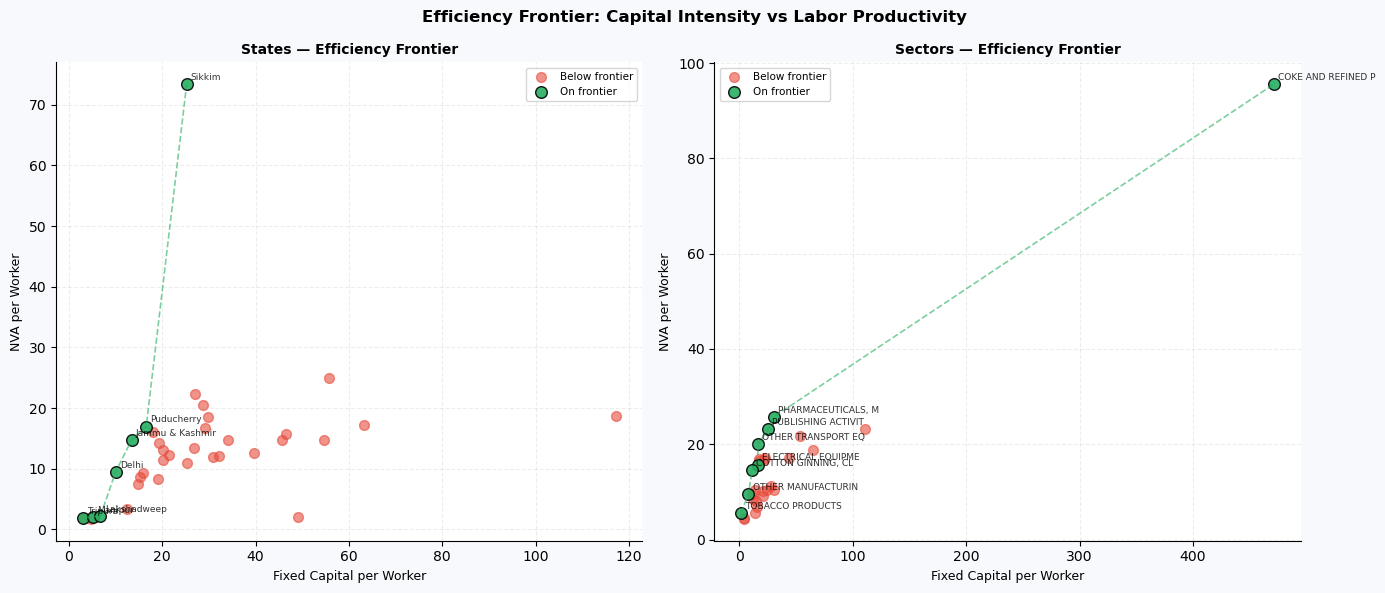

Saved: efficiency_frontier.png


In [32]:
print("\n" + "─" * 65)
print("  EFFICIENCY FRONTIER SCATTER")
print("─" * 65)

def pareto_efficient_mask(x, y):
    """Point i is on the frontier if no other point has <= capital/worker
    AND >= NVA/worker (i.e. nobody gets more output per worker for less
    capital per worker)."""
    n = len(x)
    efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and x[j] <= x[i] and y[j] >= y[i] and (x[j] < x[i] or y[j] > y[i]):
                efficient[i] = False
                break
    return efficient

state_eff_mask = pareto_efficient_mask(df_state_eff["Capital_per_Worker"].values,
                                        df_state_eff["NVA_per_Worker"].values)
sect_eff_mask  = pareto_efficient_mask(df_sect_eff["Capital_per_Worker"].values,
                                        df_sect_eff["NVA_per_Worker"].values)

fig5, (fa5, fb5) = plt.subplots(1, 2, figsize=(14, 6))
fig5.patch.set_facecolor(C["bg"])

for ax, dfe, mask, label_col, title in [
    (fa5, df_state_eff, state_eff_mask, "State", "States — Efficiency Frontier"),
    (fb5, df_sect_eff,  sect_eff_mask,  "Industry_Description", "Sectors — Efficiency Frontier"),
]:
    ax.set_facecolor(C["panel"])
    ax.scatter(dfe.loc[~mask, "Capital_per_Worker"], dfe.loc[~mask, "NVA_per_Worker"],
               color=C["under"], alpha=0.6, s=50, label="Below frontier")
    ax.scatter(dfe.loc[mask, "Capital_per_Worker"], dfe.loc[mask, "NVA_per_Worker"],
               color=C["over"], alpha=0.9, s=70, edgecolor="black", label="On frontier")
    frontier_pts = dfe.loc[mask].sort_values("Capital_per_Worker")
    ax.plot(frontier_pts["Capital_per_Worker"], frontier_pts["NVA_per_Worker"],
            color=C["over"], linestyle="--", alpha=0.6, linewidth=1.2)
    for _, r in dfe.loc[mask].iterrows():
        ax.annotate(str(r[label_col])[:18], (r["Capital_per_Worker"], r["NVA_per_Worker"]),
                    fontsize=6.5, alpha=0.8, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel("Fixed Capital per Worker", fontsize=9)
    ax.set_ylabel("NVA per Worker", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.22, linestyle="--")

fig5.suptitle("Efficiency Frontier: Capital Intensity vs Labor Productivity", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("efficiency_frontier.png", dpi=140, bbox_inches="tight", facecolor=fig5.get_facecolor())
plt.show()
print("Saved: efficiency_frontier.png")

# K-MEANS CLUSTERING — States & Sectors


─────────────────────────────────────────────────────────────────
  K-MEANS CLUSTERING — States & Sectors
─────────────────────────────────────────────────────────────────

  States clustered into k=3 groups
  Sectors clustered into k=3 groups


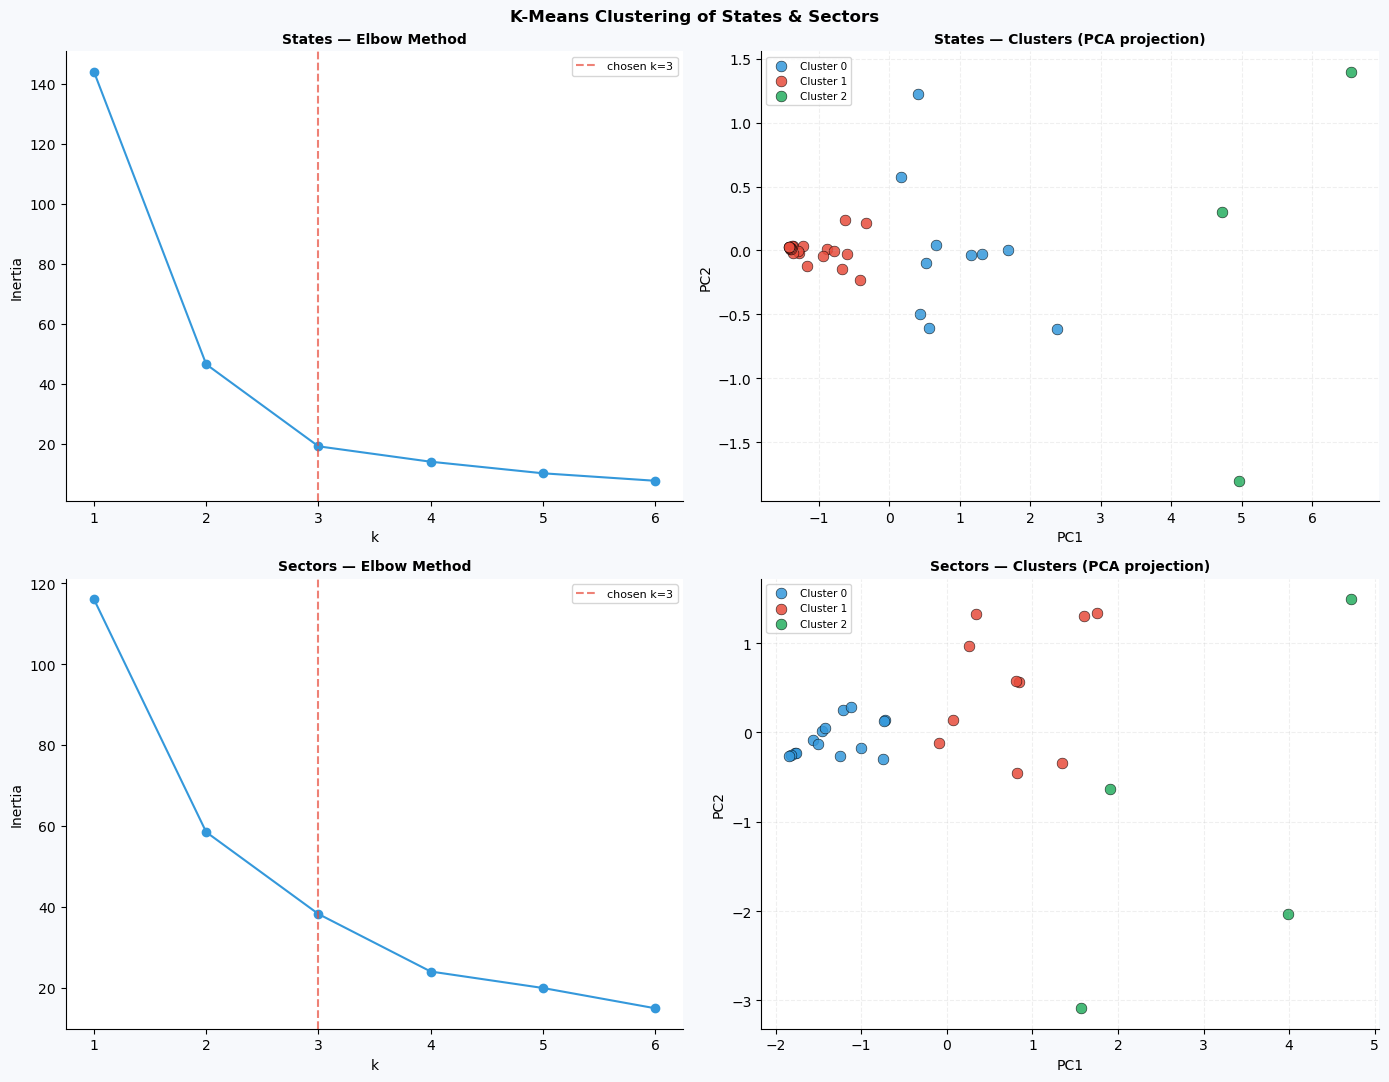

Saved: kmeans_clusters.png

  State cluster membership:
    Cluster 0 (10): Karnataka, Uttar Pradesh, Haryana, Rajasthan, Andhra Pradesh, Telangana ...
    Cluster 1 (23): Uttarakhand, Jharkhand, Chattisgarh, Himachal Pradesh, Kerala, Dadra & N Haveli & Daman & Diu ...
    Cluster 2 (3): Maharashtra, Gujarat, Tamil Nadu

  Sector cluster membership:
    Cluster 0 (15): OTHER TRANSPORT EQUIPMENT, COMPUTER, ELECTRONIC AND OPTIC, OTHER MANUFACTURING, PAPER AND PAPER PRODUCTS, BEVERAGES, TOBACCO PRODUCTS ...
    Cluster 1 (10): MOTOR VEHICLES, TRAILERS AND S, PHARMACEUTICALS, MEDICINAL CHE, MACHINERY AND EQUIPMENT N.E.C., ELECTRICAL EQUIPMENT, OTHER INDUSTRIES, OTHER NON-METALLIC MINERAL PRO ...
    Cluster 2 (4): BASIC METALS, CHEMICALS AND CHEMICAL PRODUCT, FOOD PRODUCTS, COKE AND REFINED PETROLEUM PRO


In [33]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("\n" + "─" * 65)
print("  K-MEANS CLUSTERING — States & Sectors")
print("─" * 65)

def cluster_units(df, features, max_k=6):
    X = StandardScaler().fit_transform(df[features].values)
    inertias = []
    for k in range(1, max_k + 1):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
    # heuristic elbow: largest drop in inertia after k=2
    drops = [inertias[i - 1] - inertias[i] for i in range(1, len(inertias))]
    best_k = drops.index(max(drops[1:])) + 2 if len(drops) > 1 else 3
    best_k = min(max(best_k, 3), 5)
    km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
    labels = km_final.fit_predict(X)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    out = df.copy()
    out["Cluster"] = labels
    out["PC1"], out["PC2"] = coords[:, 0], coords[:, 1]
    return out, inertias, best_k

df_state_cl, state_inertias, k_state = cluster_units(df_state, STATE_FEATS)
df_sect_cl,  sect_inertias,  k_sect  = cluster_units(df_sect,  SECTOR_FEATS)

print(f"\n  States clustered into k={k_state} groups")
print(f"  Sectors clustered into k={k_sect} groups")

fig6, axes = plt.subplots(2, 2, figsize=(14, 11))
fig6.patch.set_facecolor(C["bg"])
cluster_colors = ["#3498db", "#e74c3c", "#27ae60", "#9b59b6", "#f39c12"]

for row, (dfc, label_col, inertias, best_k, name) in enumerate([
    (df_state_cl, "State", state_inertias, k_state, "States"),
    (df_sect_cl,  "Industry_Description", sect_inertias, k_sect, "Sectors"),
]):
    ax_elbow, ax_scatter = axes[row]
    ax_elbow.set_facecolor(C["panel"])
    ax_elbow.plot(range(1, len(inertias) + 1), inertias, marker="o", color=C["rf"])
    ax_elbow.axvline(best_k, color=C["shade"], linestyle="--", alpha=0.7, label=f"chosen k={best_k}")
    ax_elbow.set_xlabel("k"); ax_elbow.set_ylabel("Inertia")
    ax_elbow.set_title(f"{name} — Elbow Method", fontsize=10, fontweight="bold")
    ax_elbow.legend(fontsize=8)
    ax_elbow.spines[["top", "right"]].set_visible(False)

    ax_scatter.set_facecolor(C["panel"])
    for c in range(best_k):
        sub = dfc[dfc["Cluster"] == c]
        ax_scatter.scatter(sub["PC1"], sub["PC2"], color=cluster_colors[c % len(cluster_colors)],
                            label=f"Cluster {c}", alpha=0.85, s=60, edgecolor="black", linewidth=0.4)
    ax_scatter.set_xlabel("PC1"); ax_scatter.set_ylabel("PC2")
    ax_scatter.set_title(f"{name} — Clusters (PCA projection)", fontsize=10, fontweight="bold")
    ax_scatter.legend(fontsize=7.5)
    ax_scatter.spines[["top", "right"]].set_visible(False)
    ax_scatter.grid(alpha=0.2, linestyle="--")

fig6.suptitle("K-Means Clustering of States & Sectors", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=140, bbox_inches="tight", facecolor=fig6.get_facecolor())
plt.show()
print("Saved: kmeans_clusters.png")

print("\n  State cluster membership:")
for c in sorted(df_state_cl["Cluster"].unique()):
    members = df_state_cl.loc[df_state_cl["Cluster"] == c, "State"].tolist()
    preview = ", ".join(members[:6]) + (" ..." if len(members) > 6 else "")
    print(f"    Cluster {c} ({len(members)}): {preview}")

print("\n  Sector cluster membership:")
for c in sorted(df_sect_cl["Cluster"].unique()):
    members = df_sect_cl.loc[df_sect_cl["Cluster"] == c, "Industry_Description"].tolist()
    preview = ", ".join(m[:30] for m in members[:6]) + (" ..." if len(members) > 6 else "")
    print(f"    Cluster {c} ({len(members)}): {preview}")

# SHAP VALUES — Model Explainability


─────────────────────────────────────────────────────────────────
  SHAP VALUES — Feature Attribution (exact Shapley, no external deps)
─────────────────────────────────────────────────────────────────

  Computing exact Shapley values (states)...
  Computing exact Shapley values (sectors)...


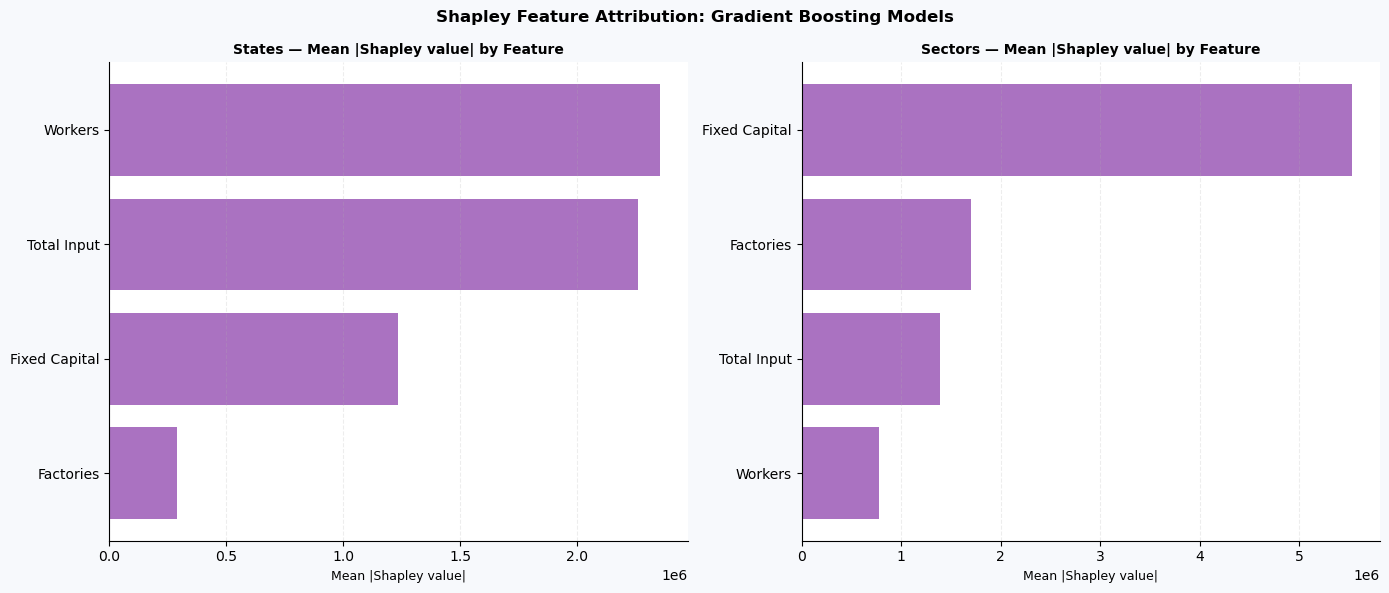

Saved: shap_importance.png


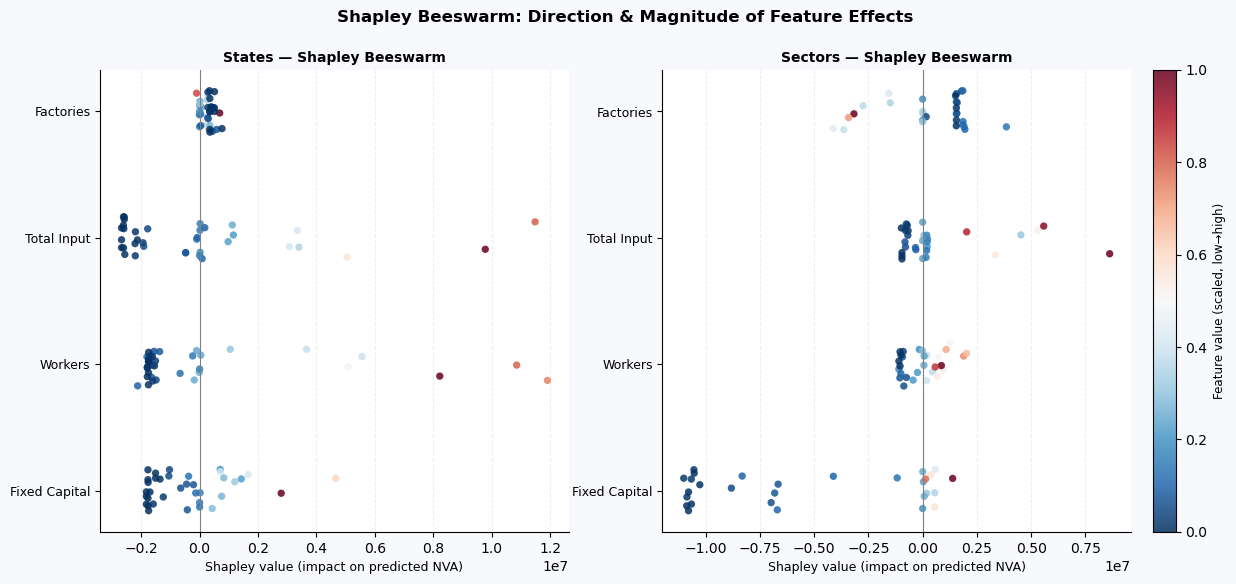

Saved: shap_summary_states.png (combined beeswarm, states + sectors)

  Sanity check — Shapley efficiency property (should be ~0):
    max reconstruction error (states):  0.000000
    max reconstruction error (sectors): 0.000000


In [37]:
print("\n" + "─" * 65)
print("  SHAP VALUES — Feature Attribution (exact Shapley, no external deps)")
print("─" * 65)

# NOTE: the `shap` package pulls in `numba`, which currently caps NumPy at
# 2.3 and breaks on newer NumPy installs. With only 4 features here, exact
# Shapley values are cheap to compute directly (2**4 = 16 coalitions per
# row) — no external library, no version conflicts, and mathematically
# exact rather than approximate.

from itertools import combinations
from math import factorial

def exact_shapley_values(model, X, baseline):
    """Exact Shapley values for a fitted regressor's predictions.

    For each row, marginalizes out 'absent' features by fixing them at
    the dataset mean (baseline), and computes the standard Shapley
    weighted-average marginal contribution over all feature subsets.
    Satisfies the efficiency property: sum(shap_vals[i]) + v(empty)
    == model.predict(row).
    """
    n, p = X.shape
    shap_vals = np.zeros((n, p))
    for i in range(n):
        row = X[i]
        # cache v(S) for every subset, encoded as a bitmask
        v_cache = {}
        for mask in range(2 ** p):
            x = baseline.copy()
            for j in range(p):
                if mask & (1 << j):
                    x[j] = row[j]
            v_cache[mask] = model.predict(x.reshape(1, -1))[0]
        for j in range(p):
            others = [f for f in range(p) if f != j]
            total = 0.0
            for r in range(len(others) + 1):
                for S in combinations(others, r):
                    s = len(S)
                    weight = factorial(s) * factorial(p - s - 1) / factorial(p)
                    mask_S  = sum(1 << f for f in S)
                    mask_Sj = mask_S | (1 << j)
                    total += weight * (v_cache[mask_Sj] - v_cache[mask_S])
            shap_vals[i, j] = total
    return shap_vals

def shap_summary(df, features, target, label_col):
    d  = df[[label_col] + features + [target]].dropna().reset_index(drop=True)
    X  = d[features].values
    y  = d[target].values
    sc = StandardScaler()
    Xs = sc.fit_transform(X)
    gb = GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                    learning_rate=0.05, random_state=42)
    gb.fit(Xs, y)
    baseline = Xs.mean(axis=0)
    shap_values = exact_shapley_values(gb, Xs, baseline)
    return shap_values, Xs, gb, baseline

print("\n  Computing exact Shapley values (states)...")
shap_state, Xs_state, gb_state, base_state = shap_summary(df_state, STATE_FEATS, STATE_TARGET, "State")
print("  Computing exact Shapley values (sectors)...")
shap_sect,  Xs_sect,  gb_sect,  base_sect  = shap_summary(df_sect, SECTOR_FEATS, SECTOR_TARGET, "Industry_Description")

fig7, (sa, sb) = plt.subplots(1, 2, figsize=(14, 6))
fig7.patch.set_facecolor(C["bg"])
for ax, shap_vals, feats, title in [
    (sa, shap_state, STATE_FEATS,  "States — Mean |Shapley value| by Feature"),
    (sb, shap_sect,  SECTOR_FEATS, "Sectors — Mean |Shapley value| by Feature"),
]:
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)
    ax.set_facecolor(C["panel"])
    ax.barh(np.array(feats)[order], mean_abs[order], color=C["gb"], alpha=0.85)
    ax.set_xlabel("Mean |Shapley value|", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.22, linestyle="--")

fig7.suptitle("Shapley Feature Attribution: Gradient Boosting Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=140, bbox_inches="tight", facecolor=fig7.get_facecolor())
plt.show()
print("Saved: shap_importance.png")

# manual beeswarm: per-feature scatter of Shapley value, colored by that
# feature's own (scaled) value — same visual idea as shap.summary_plot,
# built from scratch so it needs nothing beyond matplotlib.
def manual_beeswarm(ax, shap_vals, X_scaled, feature_names, title):
    rng = np.random.default_rng(42)
    for idx, feat in enumerate(feature_names):
        y_jitter = idx + (rng.random(len(shap_vals)) - 0.5) * 0.35
        vals = X_scaled[:, idx]
        vmin, vmax = vals.min(), vals.max()
        norm = (vals - vmin) / (vmax - vmin + 1e-9)
        sc = ax.scatter(shap_vals[:, idx], y_jitter, c=norm, cmap="RdBu_r",
                         s=28, alpha=0.85, edgecolor="none", vmin=0, vmax=1)
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names, fontsize=9)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_xlabel("Shapley value (impact on predicted NVA)", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.2, linestyle="--")
    return sc

fig8, (ba, bb) = plt.subplots(1, 2, figsize=(14, 6))
fig8.patch.set_facecolor(C["bg"])
ba.set_facecolor(C["panel"]); bb.set_facecolor(C["panel"])
sc1 = manual_beeswarm(ba, shap_state, Xs_state, STATE_FEATS,  "States — Shapley Beeswarm")
sc2 = manual_beeswarm(bb, shap_sect,  Xs_sect,  SECTOR_FEATS, "Sectors — Shapley Beeswarm")
cbar = fig8.colorbar(sc2, ax=[ba, bb], fraction=0.03, pad=0.02)
cbar.set_label("Feature value (scaled, low→high)", fontsize=8.5)
fig8.suptitle("Shapley Beeswarm: Direction & Magnitude of Feature Effects", fontsize=12, fontweight="bold")
plt.savefig("shap_summary_states.png", dpi=140, bbox_inches="tight", facecolor=fig8.get_facecolor())
plt.show()
print("Saved: shap_summary_states.png (combined beeswarm, states + sectors)")

# sanity check: efficiency property — sum(shap) + v(empty set) should
# reconstruct each row's actual model prediction, up to float error
def shapley_efficiency_error(shap_vals, model, X, baseline):
    v_empty    = model.predict(baseline.reshape(1, -1))[0]
    reconstructed = shap_vals.sum(axis=1) + v_empty
    actual = model.predict(X)
    return np.max(np.abs(reconstructed - actual))

print("\n  Sanity check — Shapley efficiency property (should be ~0):")
err_state = shapley_efficiency_error(shap_state, gb_state, Xs_state, base_state)
err_sect  = shapley_efficiency_error(shap_sect,  gb_sect,  Xs_sect,  base_sect)
print(f"    max reconstruction error (states):  {err_state:.6f}")
print(f"    max reconstruction error (sectors): {err_sect:.6f}")

# PRINTED INTERPRETATION

In [38]:
top3_state_over  = df_state.nlargest(3,  "Residual")["State"].tolist()
top3_state_under = df_state.nsmallest(3, "Residual")["State"].tolist()
top3_sect_over   = df_sect.nlargest(3,  "Residual")["Industry_Description"].str[:30].tolist()
top3_sect_under  = df_sect.nsmallest(3, "Residual")["Industry_Description"].str[:30].tolist()
state_top_feat   = state_fi.iloc[0]["Feature"]
sect_top_feat    = sect_fi.iloc[0]["Feature"]
fcast_2029       = df_fc["Forecast_PR"].iloc[-1]

# ── new: correlation, efficiency, concentration, frontier, clustering, SHAP ──
strongest_state_pair = (
    corr_state.where(~np.eye(len(corr_state), dtype=bool))
    .abs().stack().idxmax()
)
strongest_sect_pair = (
    corr_sect.where(~np.eye(len(corr_sect), dtype=bool))
    .abs().stack().idxmax()
)

top_state_prod   = df_state_eff.nlargest(3, "NVA_per_Worker")["State"].tolist()
top_sect_prod    = df_sect_eff.nlargest(3, "NVA_per_Worker")["Industry_Description"].str[:30].tolist()
bottom_state_prod = df_state_eff.nsmallest(3, "NVA_per_Worker")["State"].tolist()

def hhi_level(hhi):
    if hhi < 1500:
        return "unconcentrated / competitive"
    elif hhi < 2500:
        return "moderately concentrated"
    return "highly concentrated"

state_hhi_level = hhi_level(hhi_state)
sect_hhi_level  = hhi_level(hhi_sect)

frontier_states = df_state_eff.loc[state_eff_mask, "State"].tolist()
frontier_sects  = df_sect_eff.loc[sect_eff_mask, "Industry_Description"].str[:30].tolist()

state_shap_top = np.array(STATE_FEATS)[np.argsort(-np.abs(shap_state).mean(axis=0))[0]]
sect_shap_top  = np.array(SECTOR_FEATS)[np.argsort(-np.abs(shap_sect).mean(axis=0))[0]]

print(f"""
{"="*65}
  INTERPRETATION — COMPLETE ML ANALYSIS
{"="*65}

MODEL 1 — NATIONAL TIME SERIES FORECAST
  • Polynomial Regression (R²={r2_score(y_ts,y_pr):.4f}) outperforms Linear
    Regression (R²={r2_score(y_ts,y_lr):.4f}) — confirming Indian industrial
    output follows an accelerating, not linear, growth curve.
  • Forecast: output projected to reach Rs. {fcast_2029:,.0f} lakh
    by 2028-29 — ~{((fcast_2029/y_ts[-1])**(1/5)-1)*100:.1f}% nominal growth per year.
  • COVID impact visible as a dip in 2019-21, followed by the
    steepest single-year recovery in the 43-year series.

MODEL 2 — STATE CROSS-SECTIONAL
  • Best model: {state_best} (LOO-CV R²={max(loo_s_ridge,loo_s_rf,loo_s_gb):.4f})
  • Top driver of state NVA: '{state_top_feat}'
  • Over-performers (produce more NVA than inputs predict):
    → {", ".join(top3_state_over)}
    These states extract higher value from the same inputs —
    likely due to high-value industry mix or better efficiency.
  • Under-performers (produce less NVA than inputs predict):
    → {", ".join(top3_state_under)}
    These states have untapped potential — capital and labour
    are present but not converting efficiently into NVA.

MODEL 3 — SECTOR CROSS-SECTIONAL
  • Best model: {sect_best} (LOO-CV R²={max(loo_t_ridge,loo_t_rf,loo_t_gb):.4f})
  • Top driver of sector NVA: '{sect_top_feat}'
  • Over-performers (sectors punching above their weight):
    → {", ".join(top3_sect_over)}
  • Under-performers (sectors underperforming given their inputs):
    → {", ".join(top3_sect_under)}

FEATURE IMPORTANCE (both models):
  • '{state_top_feat}' is the primary driver of NVA across states.
  • '{sect_top_feat}' is the primary driver across sectors.
  • Both confirm the same macro finding from EDA: Indian
    industrial value creation is driven more by capital and
    material inputs than by sheer headcount.

CORRELATION STRUCTURE:
  • Strongest state-level relationship: '{strongest_state_pair[0]}' ↔
    '{strongest_state_pair[1]}' (|r|={corr_state.loc[strongest_state_pair]:.2f}).
  • Strongest sector-level relationship: '{strongest_sect_pair[0]}' ↔
    '{strongest_sect_pair[1]}' (|r|={corr_sect.loc[strongest_sect_pair]:.2f}).
  • High inter-feature correlation is expected (capital, workers,
    and input scale together) — this is why tree-based models
    (RF/GB) are preferred over Ridge for feature attribution here.

PRODUCTIVITY & EFFICIENCY RATIOS:
  • Highest NVA-per-worker states: {", ".join(top_state_prod)}.
  • Highest NVA-per-worker sectors: {", ".join(top_sect_prod)}.
  • Lowest NVA-per-worker states: {", ".join(bottom_state_prod)} —
    high headcount, comparatively low value creation per worker.

CONCENTRATION (HHI):
  • State-level NVA concentration: HHI={hhi_state:,.0f} → {state_hhi_level}.
  • Sector-level NVA concentration: HHI={hhi_sect:,.0f} → {sect_hhi_level}.
  • {"A handful of states/sectors dominate national NVA — growth "
     "policy targeted at the top contributors will move the "
     "aggregate the most." if max(hhi_state, hhi_sect) >= 1500 else
     "NVA is fairly evenly spread — no single state or sector "
     "dominates the national total."}

EFFICIENCY FRONTIER:
  • States on the capital-vs-labour productivity frontier:
    → {", ".join(frontier_states[:6])}{" ..." if len(frontier_states) > 6 else ""}
  • Sectors on the frontier:
    → {", ".join(frontier_sects[:6])}{" ..." if len(frontier_sects) > 6 else ""}
  • Units off the frontier are, by definition, achieving lower
    NVA-per-worker than some other unit with equal-or-lower
    capital-per-worker — i.e. there is room to close the gap
    without adding capital.

K-MEANS CLUSTERING:
  • States grouped into {k_state} clusters; sectors into {k_sect}
    clusters, based on scaled Fixed Capital, Workers, Total Input,
    and Factories.
  • Clusters separate broadly into large-scale/high-input units vs
    smaller-scale units — useful as a policy segmentation prior to
    targeted intervention, independent of the regression models.

SHAP VALUES (Gradient Boosting):
  • Confirms '{state_shap_top}' as the top state-level driver and
    '{sect_shap_top}' as the top sector-level driver of NVA,
    consistent with the RF/GB feature-importance ranking above —
    the tree-split-based importances and the game-theoretic SHAP
    attributions agree, which strengthens confidence in the result.

HONEST LIMITATIONS:
  • Table 2 and Table 3 are single-year (2023-24) — no time
    series per state or sector. Cross-sectional models are the
    methodologically correct approach for this data structure.
  • Nominal figures only (no inflation adjustment).
  • Small n (29-36) — results are indicative, not precise.
    LOO-CV is used specifically because it is the most
    appropriate validation strategy for small samples.
  • K-Means cluster count and the efficiency-frontier flag are
    both sensitive to which features are included — treat them
    as exploratory, not confirmatory.
{"="*65}
""")

print("ANALYSIS COMPLETE.")
print("Outputs: ml_complete.png, ml_feature_importance.png, correlation_heatmap.png,")
print("         hhi_concentration.png, efficiency_frontier.png, kmeans_clusters.png,")
print("         shap_importance.png, shap_summary_states.png, shap_summary_sectors.png")


  INTERPRETATION — COMPLETE ML ANALYSIS

MODEL 1 — NATIONAL TIME SERIES FORECAST
  • Polynomial Regression (R²=0.9954) outperforms Linear
    Regression (R²=0.9658) — confirming Indian industrial
    output follows an accelerating, not linear, growth curve.
  • Forecast: output projected to reach Rs. 2,401,084,574 lakh
    by 2028-29 — ~9.4% nominal growth per year.
  • COVID impact visible as a dip in 2019-21, followed by the
    steepest single-year recovery in the 43-year series.

MODEL 2 — STATE CROSS-SECTIONAL
  • Best model: Gradient Boosting (LOO-CV R²=0.9301)
  • Top driver of state NVA: 'Workers'
  • Over-performers (produce more NVA than inputs predict):
    → Rajasthan, Jammu & Kashmir, Sikkim
    These states extract higher value from the same inputs —
    likely due to high-value industry mix or better efficiency.
  • Under-performers (produce less NVA than inputs predict):
    → Puducherry, Punjab, Delhi
    These states have untapped potential — capital and labour
    a